In [1]:
# Importing the dependencies

import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy.stats import stats, boxcox_normmax
from scipy.special import boxcox1p

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, accuracy_score

from sklearn.model_selection import train_test_split, RepeatedKFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV, KFold

from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Exploratory Data Analysis

In [4]:
# Loading the dataset
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Checking the shape
df.shape

(284807, 31)

In [8]:
# Checking the datatypes and null/non-null distribution
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
# Checking the distribution of numerical values in the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [11]:
# Checking the class distribution of the target variable
print("Class distribution of the target variable:")
print(df["Class"].value_counts())
print("\n")

print("Class distribution of the target variable in percentage:")
print((df.groupby("Class")["Class"].count()/df["Class"].count()))

Class distribution of the target variable:
Class
0    284315
1       492
Name: count, dtype: int64


Class distribution of the target variable in percentage:
Class
0    0.998273
1    0.001727
Name: Class, dtype: float64


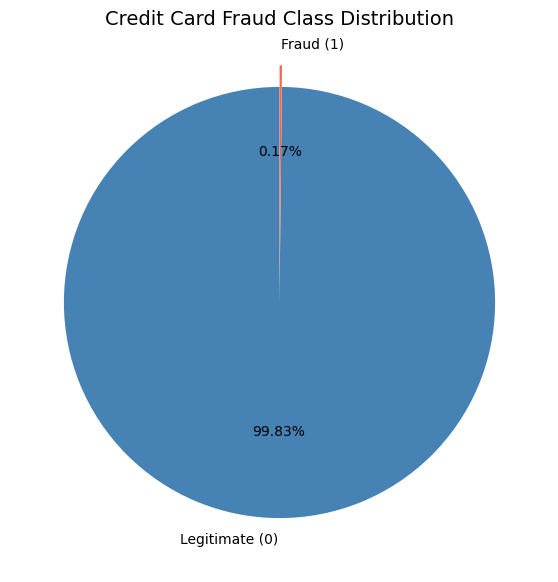

In [12]:
# Pie chart for the distribution of target variable
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    class_counts,
    labels=["Legitimate (0)", "Fraud (1)"],
    autopct="%1.2f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    explode=(0, 0.1)  # slightly explode the fraud slice
)

plt.title("Credit Card Fraud Class Distribution", fontsize=14)
plt.show()

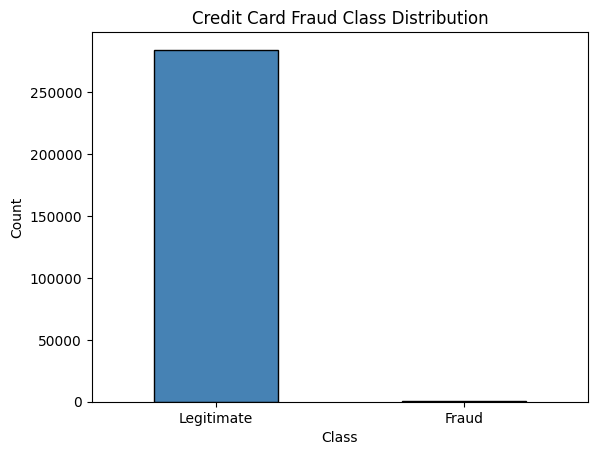

In [14]:
# Pie chart for the distribution of target variable
class_counts.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.title("Credit Card Fraud Class Distribution")
plt.ylabel("Count")
plt.show()

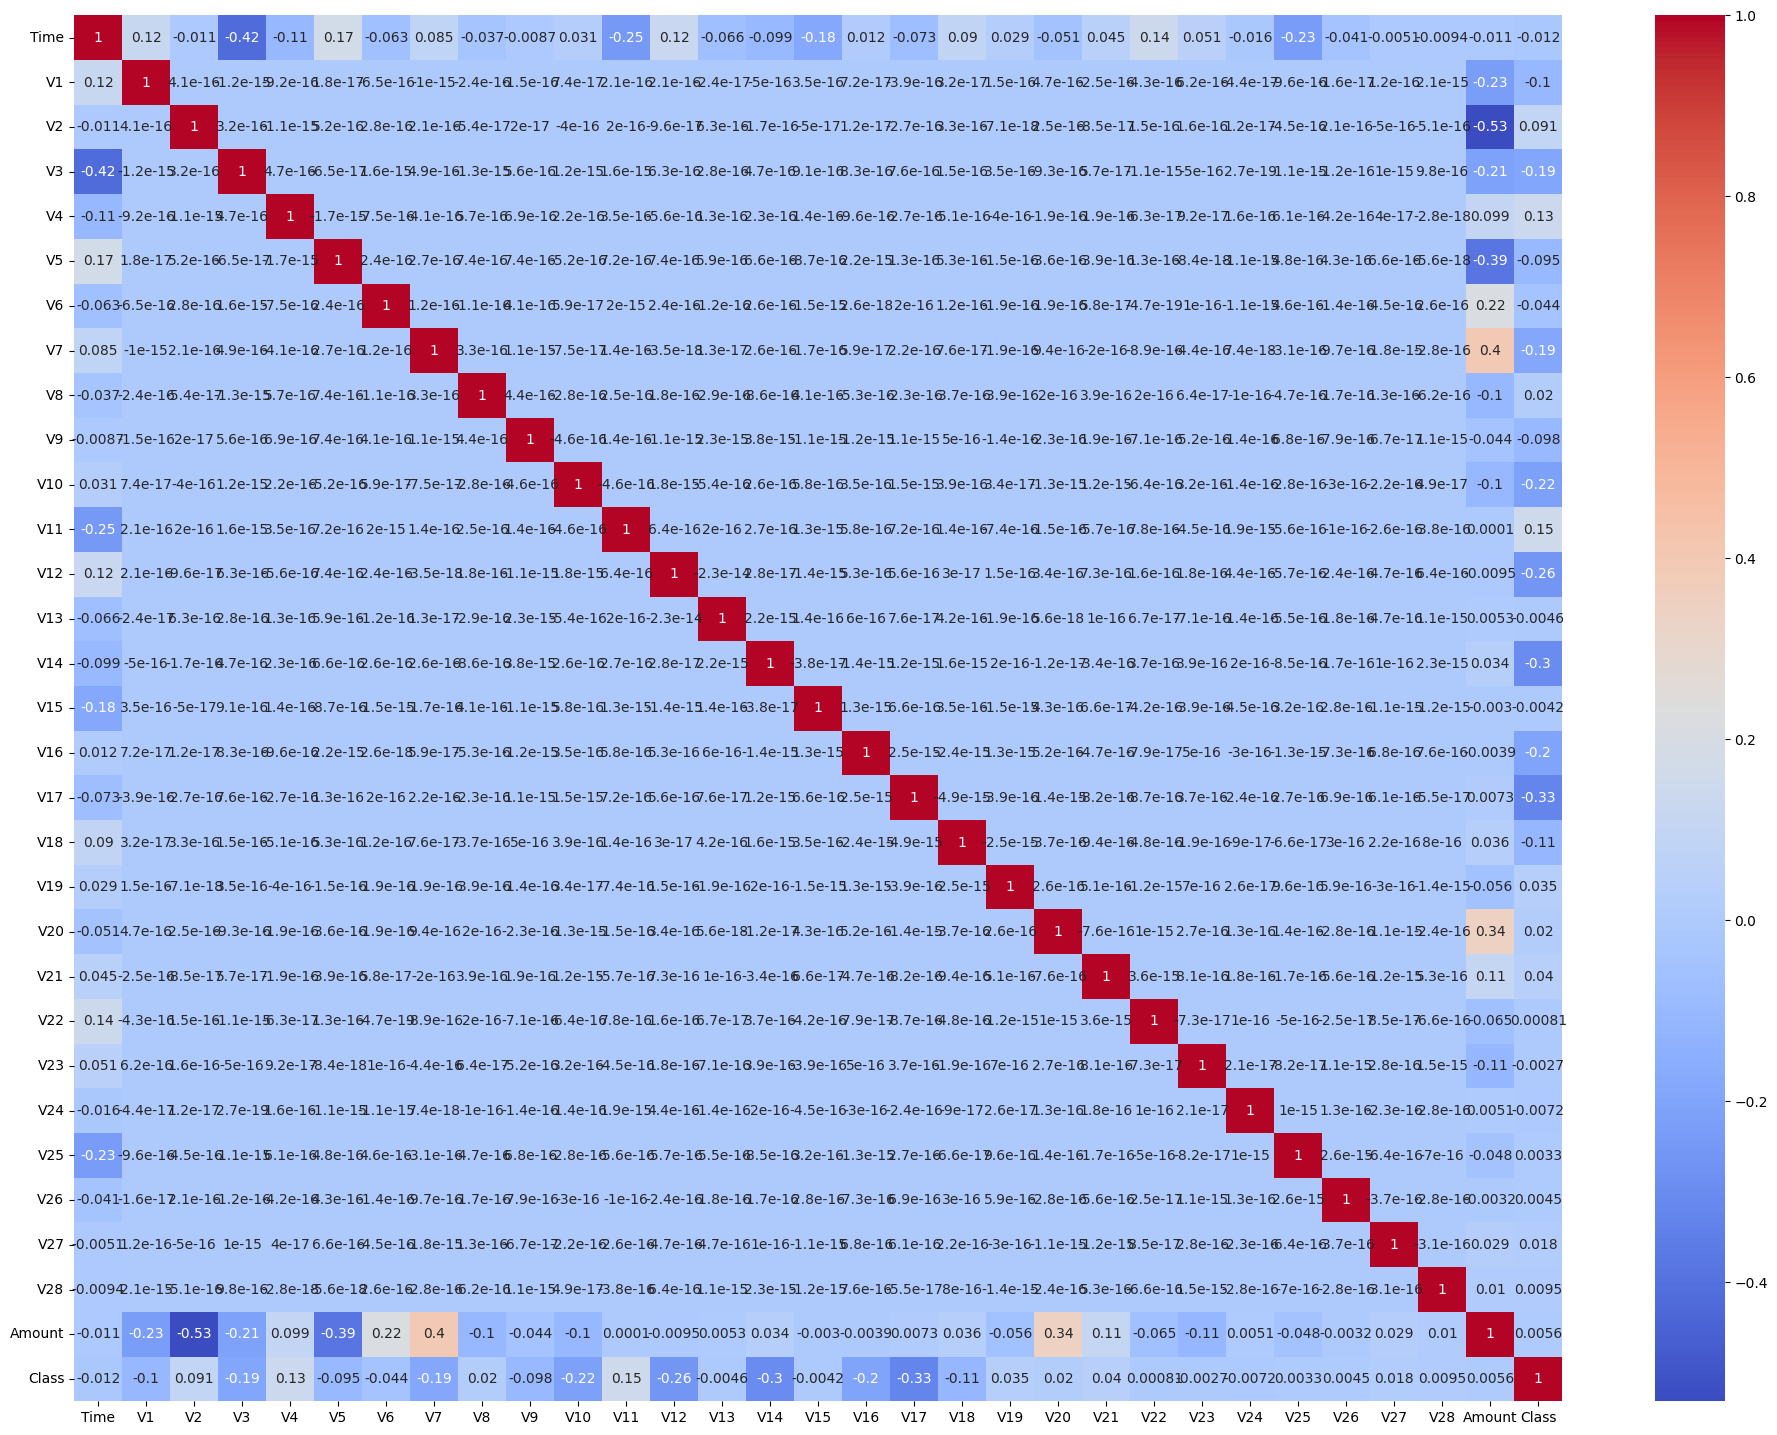

In [16]:
# Checking the correlation and plotting the heatmap
corr= df.corr()

plt.figure(figsize=(24,18))

sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

In [18]:
# Converting time into hours
delta_time= pd.to_timedelta(df["Time"], unit="s")
df["Time_Hour"]= (delta_time.dt.components.hours).astype(int)
df.drop(columns="Time", axis=1, inplace=True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0


# Splitting the dataset into training and test set

In [21]:
# Splitting the dataset into predictor and target variables
y= df["Class"]
X= df.drop(columns="Class", axis=1)

In [22]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time_Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [24]:
# Train-test split
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=100, test_size=0.2)

In [25]:
# Checking the spread of data post-split
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
396
96


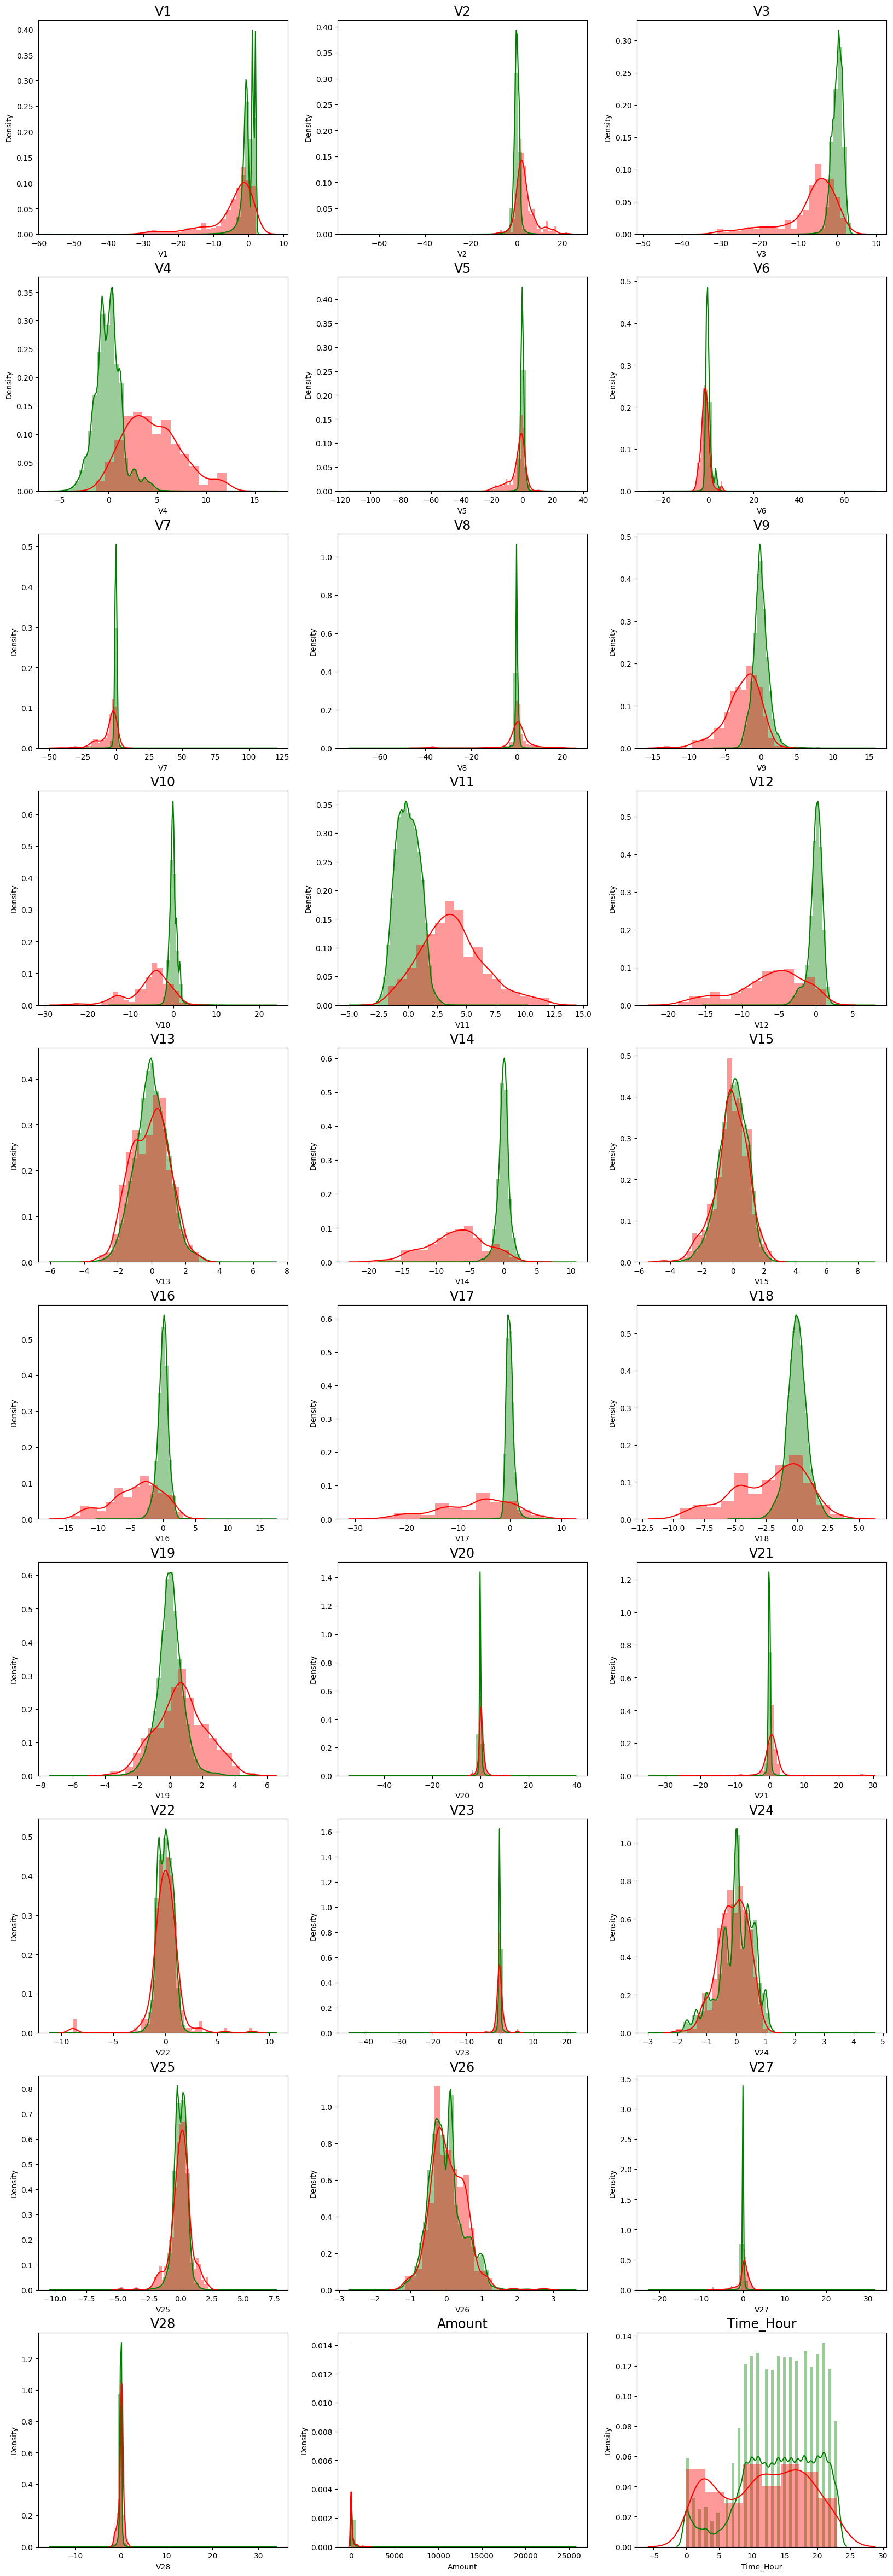

In [26]:
# Plotting the histogram of all the predictors
cols= list(X.columns.values)

normal_records= df["Class"]==0
fraud_records= df["Class"]==1

plt.figure(figsize=(20,60))
for n, col in enumerate(cols):
    plt.subplot(10, 3, n+1)
    sns.distplot(X[col][normal_records], color="green")
    sns.distplot(X[col][fraud_records], color="red")
    plt.title(col, fontsize= 17)
plt.show()

# Model Building

In [28]:
# Creating a dataframe to store results
df_results= pd.DataFrame(columns=["Methodology", "Model", "Accuracy", "roc_value", "Threshold"])

In [29]:
# Creating a common function to plot confusion matrix
def plot_confusion_matrix(y_test, pred_test):
    cm= confusion_matrix(y_test, pred_test)
    plt.clf()
    plt.imshow(cm, interpolation= "nearest", cmap= plt.cm.Accent)
    categoryNames= ["Non-fraudulent", "Fraudulent"]
    plt.title("Confusion matrix- Test data")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    ticks= np.arange(len(categoryNames))
    plt.xticks(ticks, categoryNames, rotation=45)
    plt.yticks(ticks, categoryNames)
    s= [["TN", "FP"],["FN", "TP"]]

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(s[i][j]) + " = " + str(cm[i][j]), fontsize=12)
    plt.show()

In [30]:
# Creating a common function to fit and predict on a logistic regression model
def build_and_run_logistic_model(df_results, methodology, X_train, y_train, X_test, y_test):
    num_C = list(np.power(10.0, np.arange(-10, 10)))
    cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

    searchCV_l1 = LogisticRegressionCV(
        Cs=num_C,
        penalty="l1",
        scoring="roc_auc",
        cv=cv_num,
        random_state=42,
        max_iter=10000,
        fit_intercept=True,
        solver="saga",       
        tol=1e-4             
    )
    searchCV_l2 = LogisticRegressionCV(
        Cs=num_C,
        penalty="l2",
        scoring="roc_auc",
        cv=cv_num,
        random_state=42,
        max_iter=10000,
        fit_intercept=True,
        solver="newton-cg",  
        tol=1e-4            
    )

    searchCV_l1.fit(X_train, y_train)
    searchCV_l2.fit(X_train, y_train)

    print("Max auc_roc for L1:", searchCV_l1.scores_[1].mean(axis=0).max())
    print("Max auc_roc for L2:", searchCV_l2.scores_[1].mean(axis=0).max())

    # Predictions
    y_pred_l1 = searchCV_l1.predict(X_test)
    y_pred_l2 = searchCV_l2.predict(X_test)

    # Predicted probabilities
    y_pred_probs_l1 = searchCV_l1.predict_proba(X_test)[:, 1]
    y_pred_probs_l2 = searchCV_l2.predict_proba(X_test)[:, 1]

    # --- L1 Evaluation ---
    accuracy_l1 = accuracy_score(y_pred=y_pred_l1, y_true=y_test)
    print("\nAccuracy of Logistic Regression with L1: {0}".format(accuracy_l1))
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred_l1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred_l1))

    l1_roc_value = roc_auc_score(y_test, y_pred_probs_l1)
    print("L1 ROC AUC: {0}".format(l1_roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_l1)
    threshold_l1 = thresholds[np.argmax(tpr - fpr)]
    print("L1 Optimal Threshold: {0}".format(threshold_l1))
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))
    plt.plot(fpr, tpr, label="L1 Test, auc=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - L1 Regularization")   
    plt.xlabel("False Positive Rate")            
    plt.ylabel("True Positive Rate")
    plt.legend(loc=4)
    plt.show()

    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["Logistic Regression with L1 Regularization"],
        "Accuracy": [accuracy_l1],
        "roc_value": [l1_roc_value],
        "Threshold": [threshold_l1]
    })], ignore_index=True)

    # --- L2 Evaluation ---
    accuracy_l2 = accuracy_score(y_pred=y_pred_l2, y_true=y_test)
    print("\nAccuracy of Logistic Regression with L2: {0}".format(accuracy_l2))
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred_l2)
    print("Classification Report:")
    print(classification_report(y_test, y_pred_l2))

    l2_roc_value = roc_auc_score(y_test, y_pred_probs_l2)
    print("L2 ROC AUC: {0}".format(l2_roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_l2)
    threshold_l2 = thresholds[np.argmax(tpr - fpr)]
    print("L2 Optimal Threshold: {0}".format(threshold_l2))  # Bug 3: was printing "12 threshold" (typo)
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))
    plt.plot(fpr, tpr, label="L2 Test, auc=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - L2 Regularization")   
    plt.xlabel("False Positive Rate")            
    plt.ylabel("True Positive Rate")
    plt.legend(loc=4)
    plt.show()

    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["Logistic Regression with L2 Regularization"],
        "Accuracy": [accuracy_l2],
        "roc_value": [l2_roc_value],
        "Threshold": [threshold_l2]
    })], ignore_index=True)

    return df_results

In [31]:
# Creating a common function to fit and predict on a KNN model
def build_and_run_knn_model(df_results, methodology, X_train, y_train, X_test, y_test):
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=16)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    print("Model score:")
    print(score)
    
    # Accuracy
    y_pred = knn.predict(X_test)
    knn_accuracy = accuracy_score(y_pred=y_pred, y_true=y_test)
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    knn_probs = knn.predict_proba(X_test)[:, 1]
    
    # ROC AUC
    knn_roc_value = roc_auc_score(y_test, knn_probs)
    print("KNN ROC value: {0}".format(knn_roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, knn_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("KNN Optimal Threshold: {0}".format(threshold))
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))
    plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - KNN")        
    plt.xlabel("False Positive Rate")   
    plt.ylabel("True Positive Rate")   
    plt.legend(loc=4)
    plt.show()

    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["KNN"],
        "Accuracy": [knn_accuracy],
        "roc_value": [knn_roc_value],
        "Threshold": [threshold]
    })], ignore_index=True)

    return df_results

In [32]:
# Creating a common function to fit and predict on a tree model
def build_and_run_tree_model(df_results, methodology, X_train, y_train, X_test, y_test):
    criteria = ["gini", "entropy"]

    for c in criteria:
        dt = DecisionTreeClassifier(criterion=c, random_state=42)
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)
        test_score = dt.score(X_test, y_test)
        tree_preds = dt.predict_proba(X_test)[:, 1]
        tree_roc_value = roc_auc_score(y_test, tree_preds)

        print(c + " score: {0}".format(test_score))
        print("Confusion Matrix:")
        plot_confusion_matrix(y_test, y_pred)
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print(c + " tree_roc_value: {0}".format(tree_roc_value))

        fpr, tpr, thresholds = roc_curve(y_test, tree_preds)
        threshold = thresholds[np.argmax(tpr - fpr)]
        print("Tree Optimal Threshold: {0}".format(threshold))
        roc_auc = auc(fpr, tpr)
        print("ROC AUC (test):", "{:.1%}".format(roc_auc))
        plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
        plt.title("ROC Curve - Decision Tree ({0})".format(c))  
        plt.xlabel("False Positive Rate")                        
        plt.ylabel("True Positive Rate")                        
        plt.legend(loc=4)
        plt.show()

        df_results = pd.concat([df_results, pd.DataFrame({
            "Methodology": [methodology],
            "Model": ["Tree model with {0} criteria".format(c)],
            "Accuracy": [test_score],
            "roc_value": [tree_roc_value],
            "Threshold": [threshold]
        })], ignore_index=True)

    return df_results

In [33]:
# Creating a common function to fit and predict on a random forest model
def build_and_run_random_forest_model(df_results, methodology, X_train, y_train, X_test, y_test):
    rf_model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_features="sqrt", random_state=42)
    rf_model.fit(X_train, y_train)
    rf_test_score = rf_model.score(X_test, y_test)
    print("Model accuracy: {0}".format(rf_test_score))
    
    rf_predictions = rf_model.predict(X_test)
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, rf_predictions)
    print("Classification Report:")
    print(classification_report(y_test, rf_predictions))
    
    # Calculating ROC AUC
    rf_probs = rf_model.predict_proba(X_test)[:, 1]
    roc_value = roc_auc_score(y_test, rf_probs)
    print("Random Forest ROC value: {0}".format(roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("Random Forest Optimal Threshold: {0}".format(threshold))
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))
    plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - Random Forest")  
    plt.xlabel("False Positive Rate")        
    plt.ylabel("True Positive Rate")       
    plt.legend(loc=4)
    plt.show()
    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["Random Forest"],
        "Accuracy": [rf_test_score],
        "roc_value": [roc_value],
        "Threshold": [threshold]
    })], ignore_index=True)

    return df_results

In [34]:
# Creating a common function to fit and predict on an XGBoost model
def build_and_run_xgboost_model(df_results, methodology, X_train, y_train, X_test, y_test):
    xgb_model = XGBClassifier(random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)  
    xgb_test_score = xgb_model.score(X_test, y_test)
    print("Model accuracy: {0}".format(xgb_test_score))
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
    
    # Calculating ROC AUC
    xgb_roc_value = roc_auc_score(y_test, xgb_probs)
    print("XGBoost ROC value: {0}".format(xgb_roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("XGBoost Optimal Threshold: {0}".format(threshold))
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))   
    plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - XGBoost")   
    plt.xlabel("False Positive Rate")   
    plt.ylabel("True Positive Rate")    
    plt.legend(loc=4)
    plt.show()
    
    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["XGBoost"],
        "Accuracy": [xgb_test_score],
        "roc_value": [xgb_roc_value],
        "Threshold": [threshold]
    })], ignore_index=True)
    
    return df_results

In [35]:
# Creating a common function to fit and predict on an SVM model
def build_and_run_svm_model(df_results, methodology, X_train, y_train, X_test, y_test):
    clf = SVC(kernel="sigmoid", probability=True, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    svm_score = accuracy_score(y_test, y_pred)
    print("Accuracy score: {0}".format(svm_score))
    
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    svm_probs = clf.predict_proba(X_test)[:, 1]
    
    # Calculating ROC AUC
    roc_value = roc_auc_score(y_test, svm_probs)
    print("SVM ROC value: {0}".format(roc_value))
    fpr, tpr, thresholds = roc_curve(y_test, svm_probs)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("SVM Optimal Threshold: {0}".format(threshold))
    roc_auc = auc(fpr, tpr)
    print("ROC AUC (test):", "{:.1%}".format(roc_auc))
    plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
    plt.title("ROC Curve - SVM")        
    plt.xlabel("False Positive Rate")   
    plt.ylabel("True Positive Rate")   
    plt.legend(loc=4)
    plt.show()
    
    df_results = pd.concat([df_results, pd.DataFrame({
        "Methodology": [methodology],
        "Model": ["SVM"],
        "Accuracy": [svm_score],
        "roc_value": [roc_value],
        "Threshold": [threshold]
    })], ignore_index=True)

    return df_results

# Cross Validation with RepeatedKFold

In [37]:
rkf= RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

for train_index, test_index in rkf.split(X,y):
    X_train_cv, X_test_cv= X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv= y.iloc[train_index], y.iloc[test_index]

Logistic Regression with L1 and L2 Regularization
------------------------------------------------------------
Max auc_roc for L1: 0.5659670633042149
Max auc_roc for L2: 0.9819836260634014

Accuracy of Logistic Regression with L1: 0.9982444128438757
Confusion Matrix:


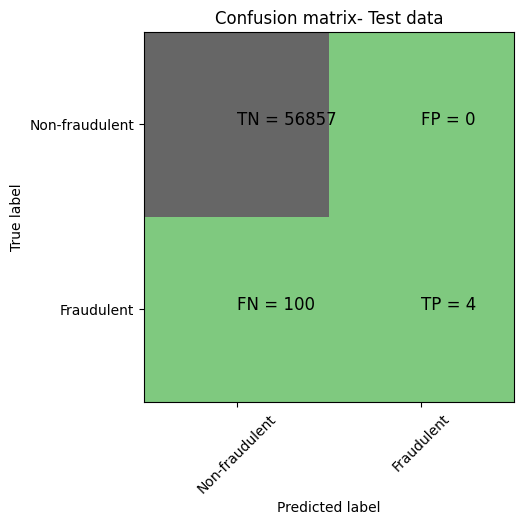

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       1.00      0.04      0.07       104

    accuracy                           1.00     56961
   macro avg       1.00      0.52      0.54     56961
weighted avg       1.00      1.00      1.00     56961

L1 ROC AUC: 0.5670800632085082
L1 Optimal Threshold: 0.020939127692314274
ROC AUC (test): 56.7%


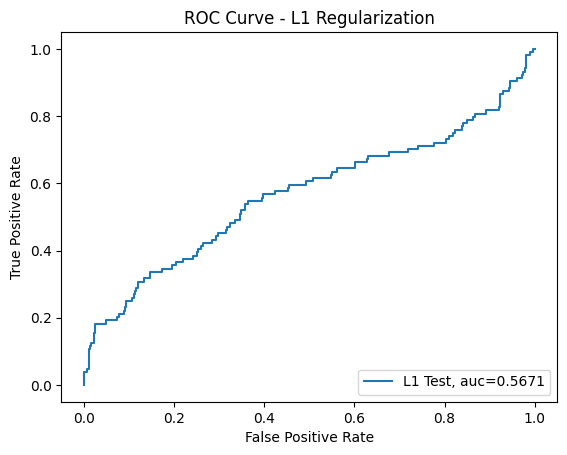


Accuracy of Logistic Regression with L2: 0.9988939800916417
Confusion Matrix:


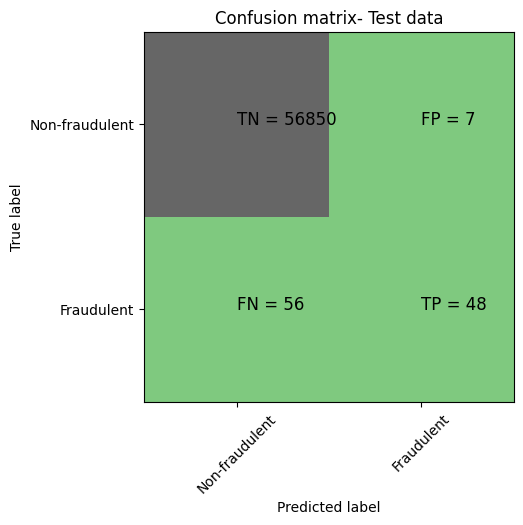

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.87      0.46      0.60       104

    accuracy                           1.00     56961
   macro avg       0.94      0.73      0.80     56961
weighted avg       1.00      1.00      1.00     56961

L2 ROC AUC: 0.9922766765745643
L2 Optimal Threshold: 0.0015960506705921115
ROC AUC (test): 99.2%


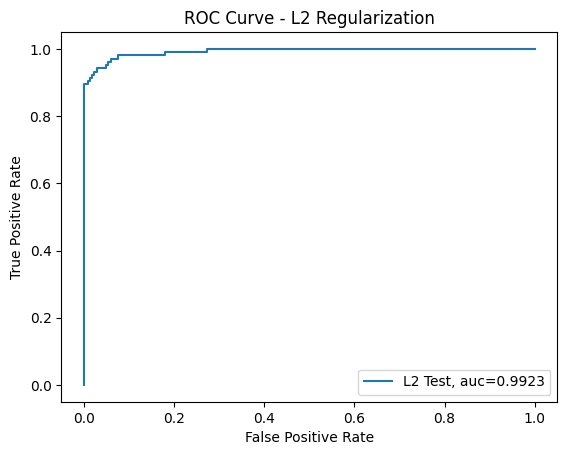

Time taken by model: --- 10327.65 seconds ---
------------------------------------------------------------
KNN Model
------------------------------------------------------------
Model score:
0.9991397622934991
Confusion Matrix:


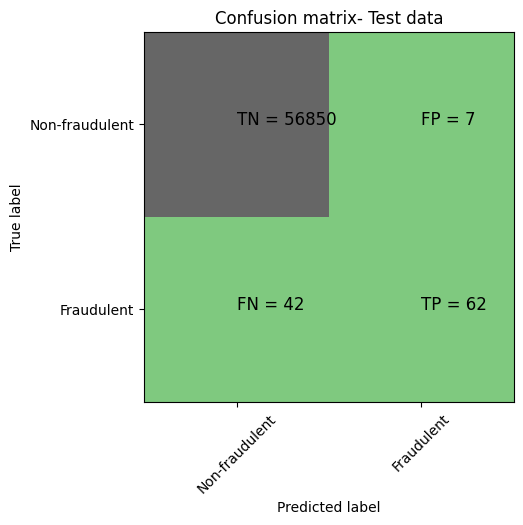

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.90      0.60      0.72       104

    accuracy                           1.00     56961
   macro avg       0.95      0.80      0.86     56961
weighted avg       1.00      1.00      1.00     56961

KNN ROC value: 0.874745904367367
KNN Optimal Threshold: 0.2
ROC AUC (test): 87.5%


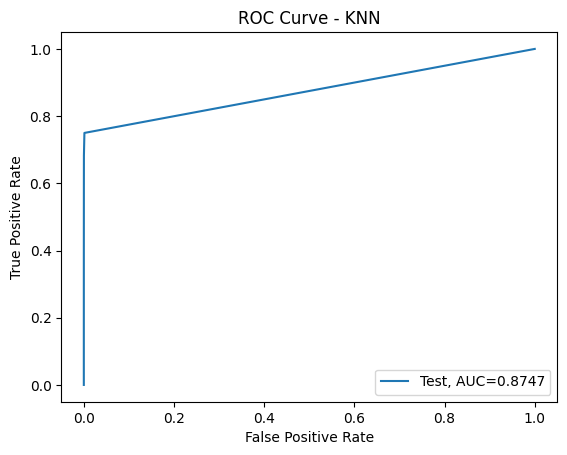

Time taken by model: --- 88.56 seconds ---
------------------------------------------------------------
Decision Tree Model
------------------------------------------------------------
gini score: 0.9991046505503766
Confusion Matrix:


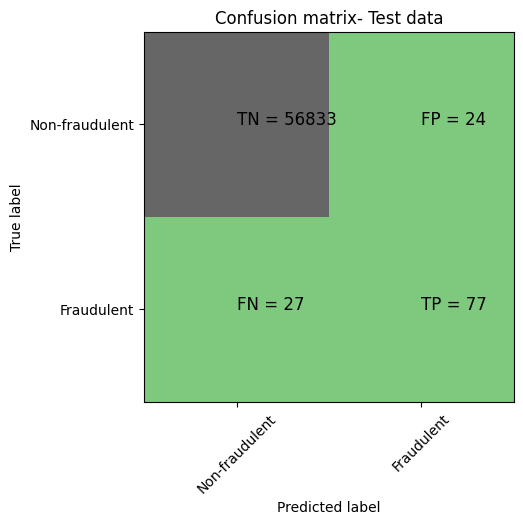

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.76      0.74      0.75       104

    accuracy                           1.00     56961
   macro avg       0.88      0.87      0.88     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8699812518856349
Tree Optimal Threshold: 1.0
ROC AUC (test): 87.0%


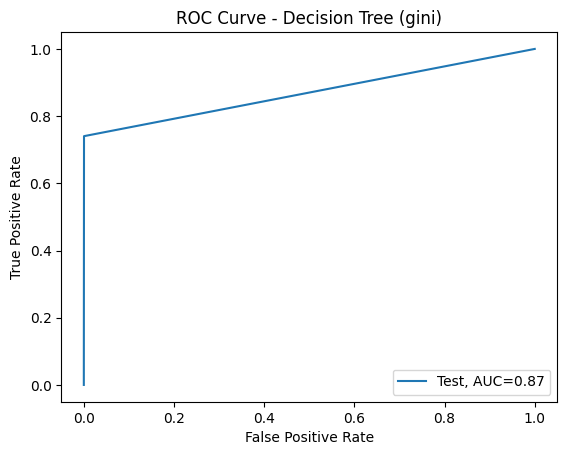

entropy score: 0.9993153210091115
Confusion Matrix:


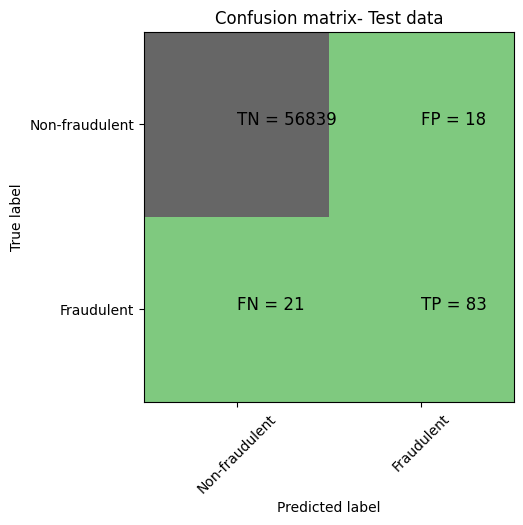

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.82      0.80      0.81       104

    accuracy                           1.00     56961
   macro avg       0.91      0.90      0.90     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.898880169683457
Tree Optimal Threshold: 1.0
ROC AUC (test): 89.9%


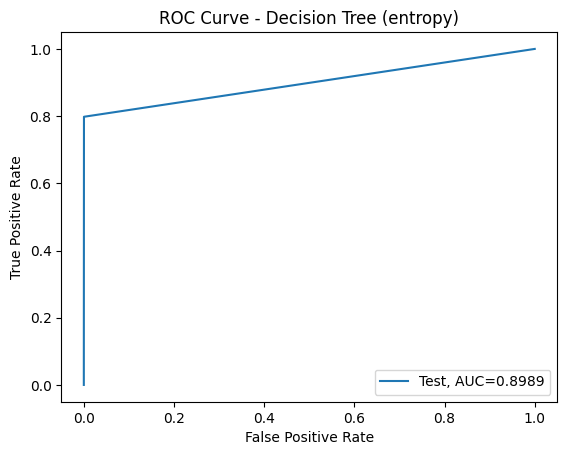

Time taken by model: --- 48.42 seconds ---
------------------------------------------------------------
Random Forest Model
------------------------------------------------------------
Model accuracy: 0.9995435473394076
Confusion Matrix:


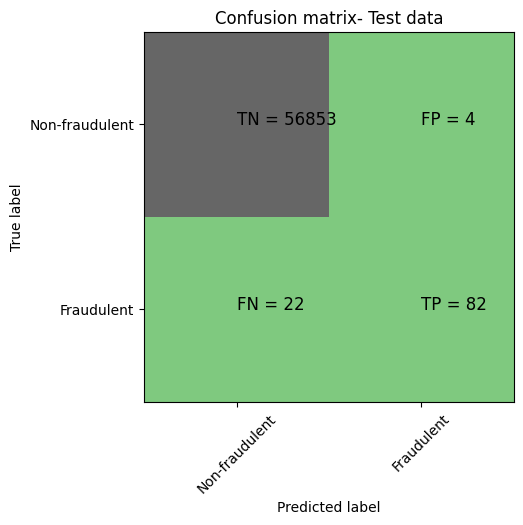

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.95      0.79      0.86       104

    accuracy                           1.00     56961
   macro avg       0.98      0.89      0.93     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest ROC value: 0.9555007096075038
Random Forest Optimal Threshold: 0.02
ROC AUC (test): 95.6%


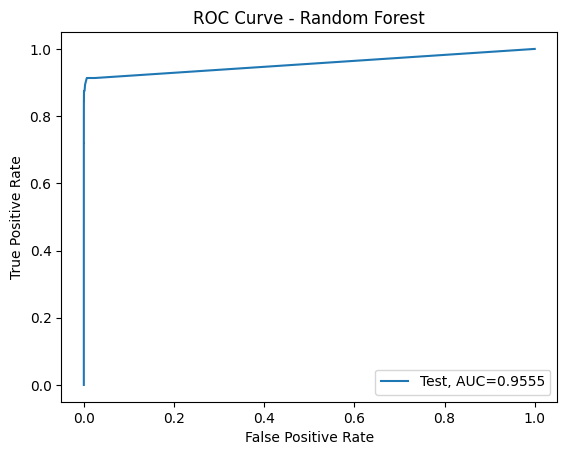

Time taken by model: --- 306.51 seconds ---
------------------------------------------------------------
XGBoost Model
------------------------------------------------------------
Model accuracy: 0.999490879724724
Confusion Matrix:


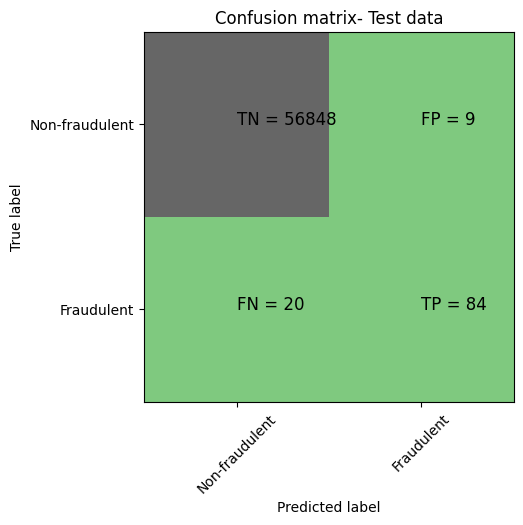

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.90      0.81      0.85       104

    accuracy                           1.00     56961
   macro avg       0.95      0.90      0.93     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost ROC value: 0.9762312772529192
XGBoost Optimal Threshold: 7.577964424854144e-05
ROC AUC (test): 97.6%


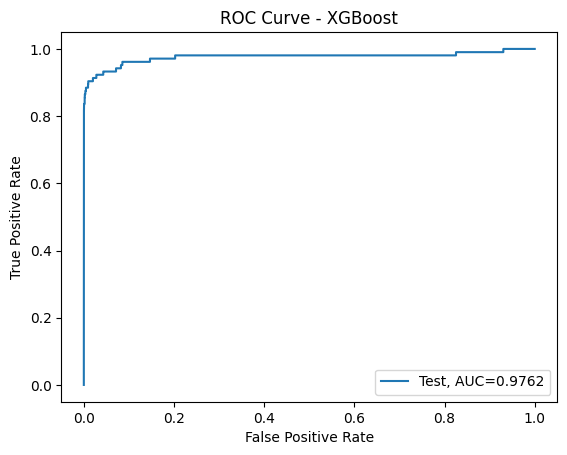

Time taken by model: --- 2.43 seconds ---
------------------------------------------------------------
SVM Model
------------------------------------------------------------
Accuracy score: 0.9981741893576307
Confusion Matrix:


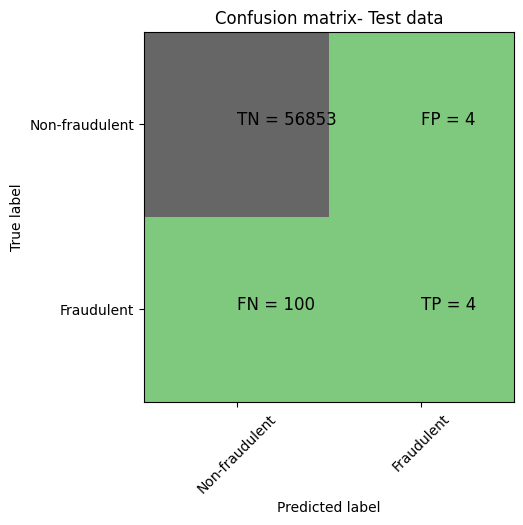

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56857
           1       0.50      0.04      0.07       104

    accuracy                           1.00     56961
   macro avg       0.75      0.52      0.54     56961
weighted avg       1.00      1.00      1.00     56961

SVM ROC value: 0.45391085733303926
SVM Optimal Threshold: 0.00428719023853639
ROC AUC (test): 45.4%


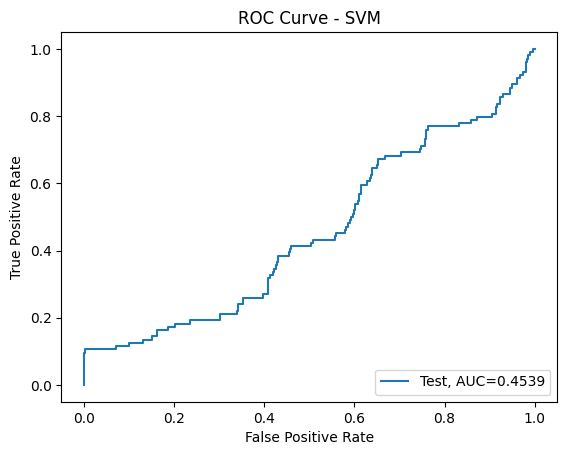

Time taken by model: --- 179.13 seconds ---
------------------------------------------------------------


In [38]:
# Logistic Regression with L1 and L2 regularization
print("Logistic Regression with L1 and L2 Regularization")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_logistic_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# KNN Model
print("KNN Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_knn_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Decision Tree Model
print("Decision Tree Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_tree_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Random Forest Model
print("Random Forest Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_random_forest_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# XGBoost Model
print("XGBoost Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_xgboost_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# SVM Model
print("SVM Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_svm_model(df_results, "RepeatedKFold Cross Validation", X_train_cv, y_train_cv, X_test_cv, y_test_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

In [39]:
df_results

,Methodology,Model,Accuracy,roc_value,Threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998244,0.567080,0.020939
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularization,0.998894,0.992277,0.001596
2,RepeatedKFold Cross Validation,KNN,0.999140,0.874746,0.200000
3,RepeatedKFold Cross Validation,Tree model with gini criteria,0.999105,0.869981,1.000000
4,RepeatedKFold Cross Validation,Tree model with entropy criteria,0.999315,0.898880,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999544,0.955501,0.020000
6,RepeatedKFold Cross Validation,XGBoost,0.999491,0.976231,0.000076
7,RepeatedKFold Cross Validation,SVM,0.998174,0.453911,0.004287


# Cross Validation with StratifiedKFold

In [42]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(X, y):
    X_train_skf_cv, X_test_skf_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_skf_cv, y_test_skf_cv = y.iloc[train_index], y.iloc[test_index]

Logistic Regression with L1 and L2 Regularization
------------------------------------------------------------
Max auc_roc for L1: 0.5557348894842584
Max auc_roc for L2: 0.9832523433536553

Accuracy of Logistic Regression with L1: 0.9983497480732431
Confusion Matrix:


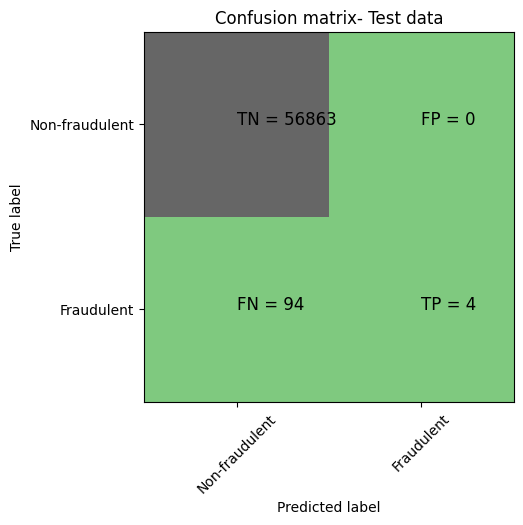

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      0.04      0.08        98

    accuracy                           1.00     56961
   macro avg       1.00      0.52      0.54     56961
weighted avg       1.00      1.00      1.00     56961

L1 ROC AUC: 0.5887586239321362
L1 Optimal Threshold: 0.012469260276940878
ROC AUC (test): 58.9%


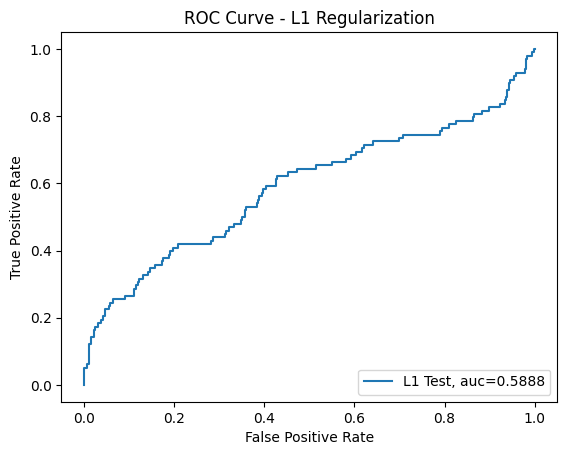


Accuracy of Logistic Regression with L2: 0.9990870946788153
Confusion Matrix:


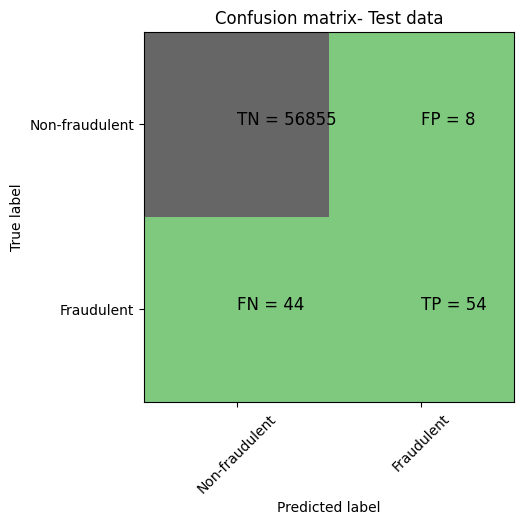

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.87      0.55      0.68        98

    accuracy                           1.00     56961
   macro avg       0.94      0.78      0.84     56961
weighted avg       1.00      1.00      1.00     56961

L2 ROC AUC: 0.9819975472734861
L2 Optimal Threshold: 0.0018791068828275601
ROC AUC (test): 98.2%


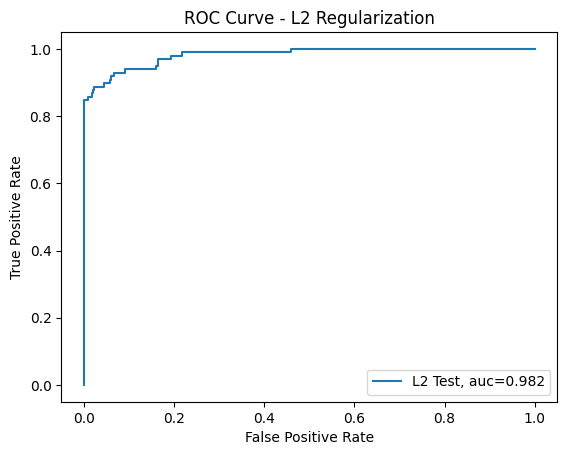

Time taken by model: --- 10194.51 seconds ---
------------------------------------------------------------
KNN Model
------------------------------------------------------------
Model score:
0.9991397622934991
Confusion Matrix:


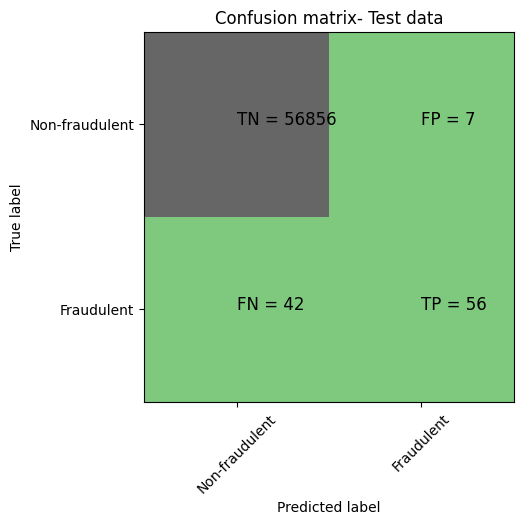

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.89      0.57      0.70        98

    accuracy                           1.00     56961
   macro avg       0.94      0.79      0.85     56961
weighted avg       1.00      1.00      1.00     56961

KNN ROC value: 0.8773440245028599
KNN Optimal Threshold: 0.2
ROC AUC (test): 87.7%


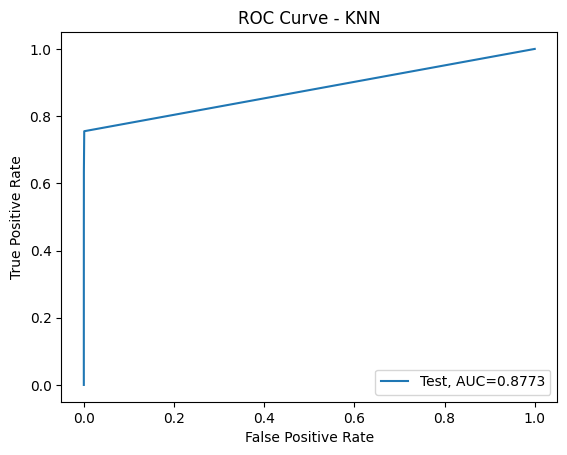

Time taken by model: --- 86.62 seconds ---
------------------------------------------------------------
Decision Tree Model
------------------------------------------------------------
gini score: 0.9990168711925703
Confusion Matrix:


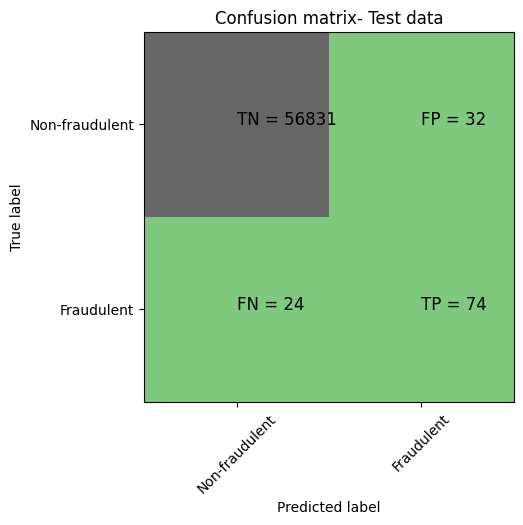

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.70      0.76      0.73        98

    accuracy                           1.00     56961
   macro avg       0.85      0.88      0.86     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8772696423591683
Tree Optimal Threshold: 1.0
ROC AUC (test): 87.7%


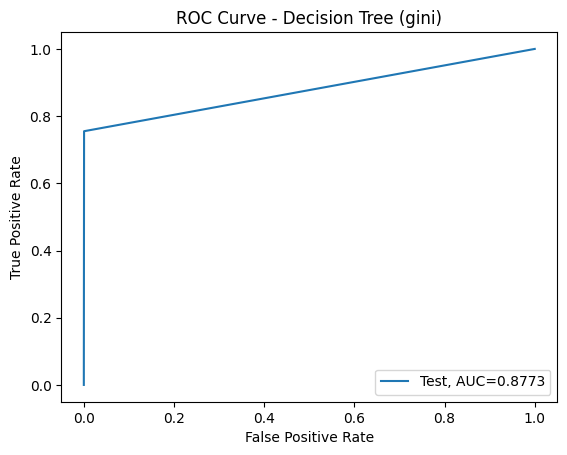

entropy score: 0.9990344270641316
Confusion Matrix:


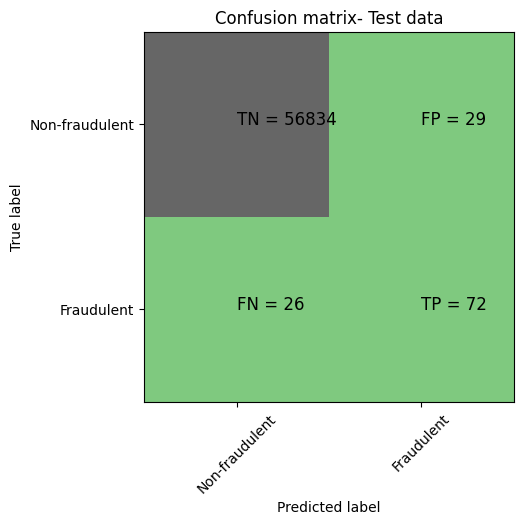

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.71      0.73      0.72        98

    accuracy                           1.00     56961
   macro avg       0.86      0.87      0.86     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8670919399186086
Tree Optimal Threshold: 1.0
ROC AUC (test): 86.7%


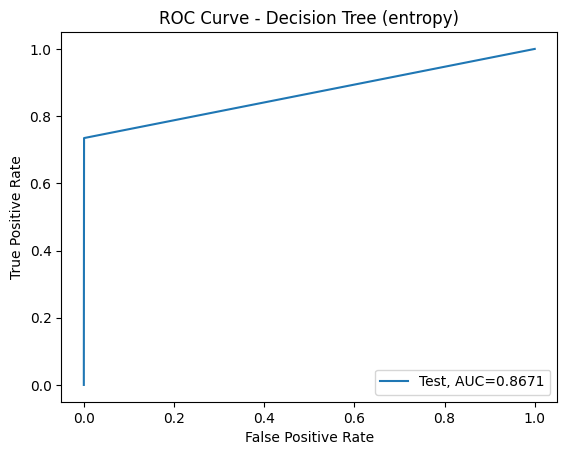

Time taken by model: --- 46.24 seconds ---
------------------------------------------------------------
Random Forest Model
------------------------------------------------------------
Model accuracy: 0.9995435473394076
Confusion Matrix:


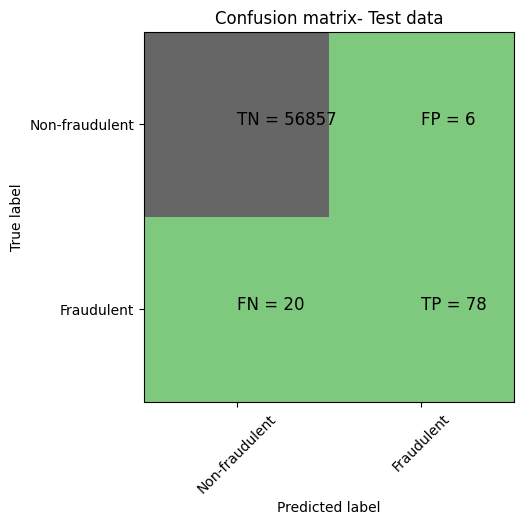

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.93      0.80      0.86        98

    accuracy                           1.00     56961
   macro avg       0.96      0.90      0.93     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest ROC value: 0.9268086884086241
Random Forest Optimal Threshold: 0.05
ROC AUC (test): 92.7%


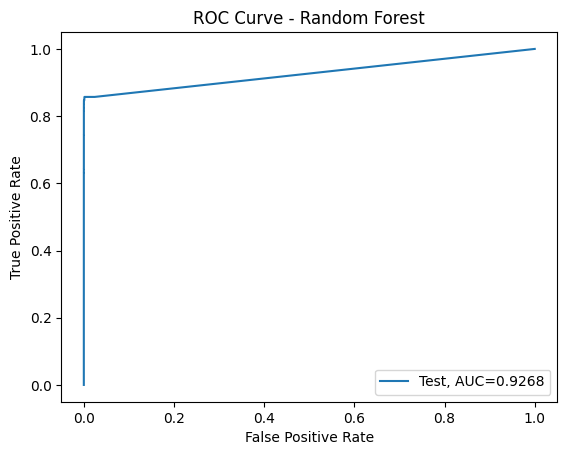

Time taken by model: --- 296.53 seconds ---
------------------------------------------------------------
XGBoost Model
------------------------------------------------------------
Model accuracy: 0.9993679886237953
Confusion Matrix:


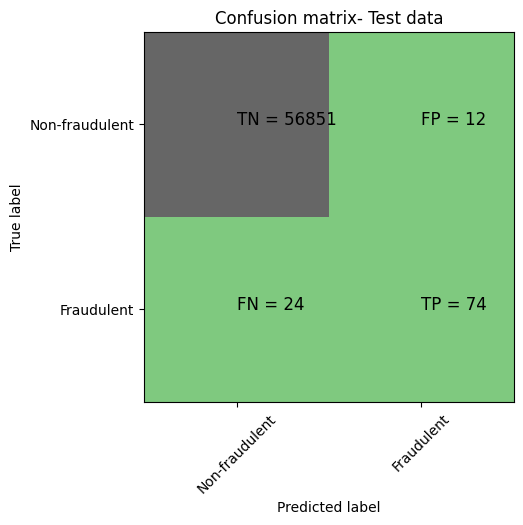

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.86      0.76      0.80        98

    accuracy                           1.00     56961
   macro avg       0.93      0.88      0.90     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost ROC value: 0.9100885874283589
XGBoost Optimal Threshold: 0.00724991038441658
ROC AUC (test): 91.0%


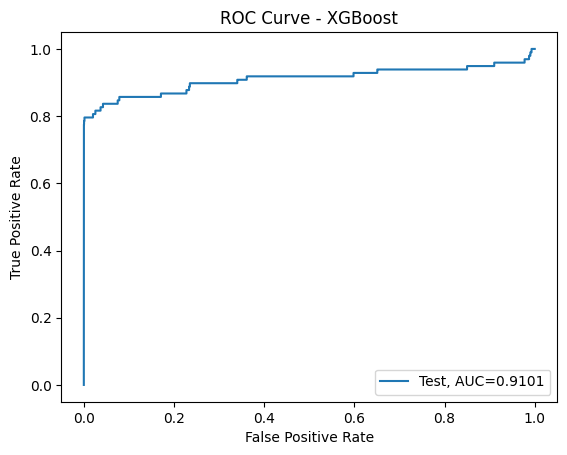

Time taken by model: --- 2.60 seconds ---
------------------------------------------------------------
SVM Model
------------------------------------------------------------
Accuracy score: 0.9983497480732431
Confusion Matrix:


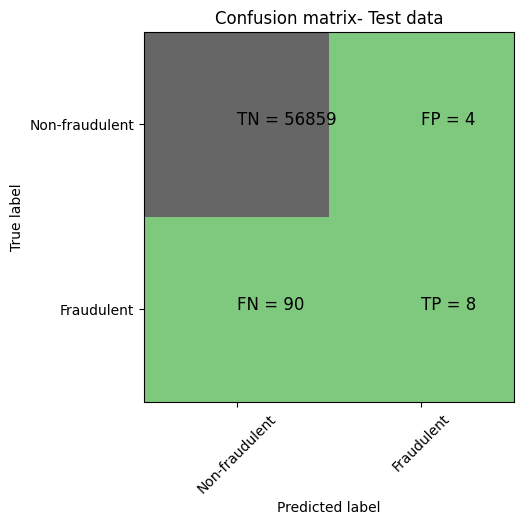

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.67      0.08      0.15        98

    accuracy                           1.00     56961
   macro avg       0.83      0.54      0.57     56961
weighted avg       1.00      1.00      1.00     56961

SVM ROC value: 0.48111465186464997
SVM Optimal Threshold: 0.0022995563504785935
ROC AUC (test): 48.1%


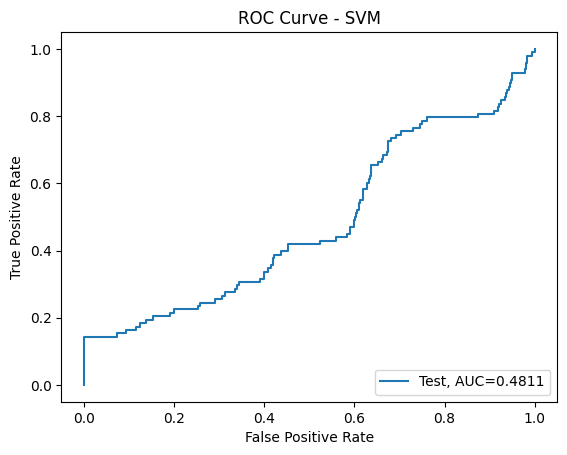

Time taken by model: --- 379.66 seconds ---
------------------------------------------------------------


In [43]:
# Logistic Regression with L1 and L2 regularization
print("Logistic Regression with L1 and L2 Regularization")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_logistic_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# KNN Model
print("KNN Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_knn_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Decision Tree Model
print("Decision Tree Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_tree_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Random Forest Model
print("Random Forest Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_random_forest_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# XGBoost Model
print("XGBoost Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_xgboost_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# SVM Model
print("SVM Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_svm_model(df_results, "StratifiedKFold Cross Validation", X_train_skf_cv, y_train_skf_cv, X_test_skf_cv, y_test_skf_cv)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

In [44]:
df_results

,Methodology,Model,Accuracy,roc_value,Threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998244,0.567080,0.020939
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularization,0.998894,0.992277,0.001596
2,RepeatedKFold Cross Validation,KNN,0.999140,0.874746,0.200000
3,RepeatedKFold Cross Validation,Tree model with gini criteria,0.999105,0.869981,1.000000
4,RepeatedKFold Cross Validation,Tree model with entropy criteria,0.999315,0.898880,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999544,0.955501,0.020000
6,RepeatedKFold Cross Validation,XGBoost,0.999491,0.976231,0.000076
7,RepeatedKFold Cross Validation,SVM,0.998174,0.453911,0.004287
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998350,0.588759,0.012469
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularization,0.999087,0.981998,0.001879


#### Logistic Regression with L2 Regularization with RepeatedKFold Cross Validation provides the best result.

In [46]:
num_c = list(np.power(10.0, np.arange(-10, 10)))
cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

clf = LogisticRegressionCV(
    Cs=num_c,
    penalty="l2",
    scoring="roc_auc",
    cv=cv_num,
    random_state=42,
    max_iter=10000,
    fit_intercept=True,
    solver="newton-cg",
    tol=1e-4             
)

clf.fit(X_train_skf_cv, y_train_skf_cv)

print("Max AUC ROC for L2:", clf.scores_[1].mean(axis=0).max())
print("Parameters for L2 Regularization")
print(clf.coef_)
print(clf.intercept_)
print(clf.scores_)

# Predicting on test set
y_pred_l2 = clf.predict(X_test)
y_pred_probs_l2 = clf.predict_proba(X_test)[:, 1]

accuracy_l2 = accuracy_score(y_pred=y_pred_l2, y_true=y_test)
print("Accuracy of Logistic Regression with L2 Regularization: {0}".format(accuracy_l2))

l2_roc_value = roc_auc_score(y_test, y_pred_probs_l2)
print("L2 ROC value: {0}".format(l2_roc_value))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_l2)
threshold = thresholds[np.argmax(tpr - fpr)]
print("L2 Optimal Threshold: {0}".format(threshold))

Max AUC ROC for L2: 0.9832523433536553
Parameters for L2 Regularization
[[ 7.96343159e-03  4.31276227e-02 -8.15797856e-02  2.39098861e-01
   8.98409978e-02 -4.66955354e-02 -3.61355491e-02 -1.13012719e-01
  -8.55120471e-02 -1.78088970e-01  1.34829711e-01 -1.97193584e-01
  -4.01109572e-02 -3.83600355e-01 -1.39642960e-02 -1.05127349e-01
  -8.81675908e-02 -5.34107761e-03  1.46991390e-02 -1.88279648e-02
   4.35465960e-02  2.53848636e-02 -1.32896572e-02 -1.61375367e-02
  -6.49650691e-03  7.15458781e-03 -2.47923547e-03  2.25195708e-03
   3.31386813e-04  2.24951261e-02]]
[-7.75979942]
{1: array([[0.53798997, 0.54007469, 0.56370534, 0.73210117, 0.92883388,
        0.98617863, 0.99734609, 0.99741898, 0.9965999 , 0.99377477,
        0.99377477, 0.99377477, 0.99377477, 0.99377477, 0.99377477,
        0.99377477, 0.99377477, 0.99377477, 0.99377477, 0.99377477],
       [0.70175281, 0.70349684, 0.72030845, 0.8288268 , 0.94281045,
        0.97524563, 0.98279632, 0.97676152, 0.97963443, 0.98036787,
   

In [47]:
# Creating a dataframe with coefficient values
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(clf.coef_))], axis=1)
coefficients.columns = ["Feature", "Coefficient Value"]

coefficients = coefficients.reindex(
    coefficients["Coefficient Value"].abs().sort_values(ascending=False).index
)
coefficients

,Feature,Coefficient Value
13,V14,-0.383600
3,V4,0.239099
11,V12,-0.197194
9,V10,-0.178089
10,V11,0.134830
7,V8,-0.113013
15,V16,-0.105127
4,V5,0.089841
16,V17,-0.088168
8,V9,-0.085512


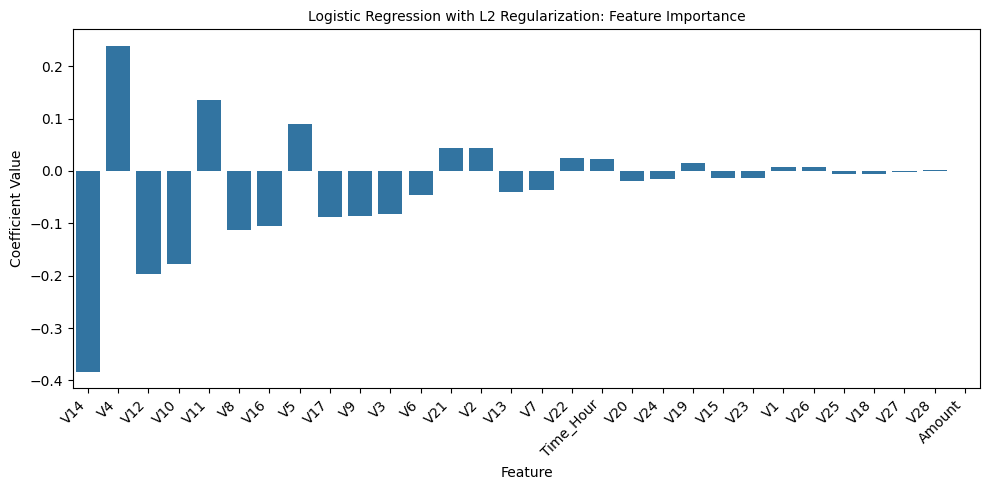

In [48]:
# Plotting the coefficient values
plt.figure(figsize=(10, 5))
sns.barplot(x="Feature", y="Coefficient Value", data=coefficients)
plt.title("Logistic Regression with L2 Regularization: Feature Importance", fontsize=10)
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()                  
plt.show()

# Model Building with Balanced Classes

## RandomOverSampler

In [50]:
# Creating the dataset with RandomOverSampler and StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]
    ros = RandomOverSampler(sampling_strategy=0.5, random_state=42)
    X_over, y_over = ros.fit_resample(X_train, y_train)

X_over = pd.DataFrame(data=X_over, columns=cols)

Logistic Regression with L1 and L2 Regularization
------------------------------------------------------------
Max auc_roc for L1: 0.9623986230925198
Max auc_roc for L2: 0.9873458667143128

Accuracy of Logistic Regression with L1: 0.9875528870630782
Confusion Matrix:


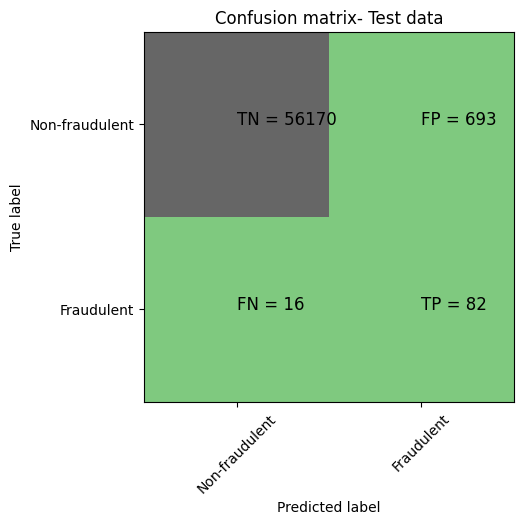

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.11      0.84      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.91      0.59     56961
weighted avg       1.00      0.99      0.99     56961

L1 ROC AUC: 0.9445907761835014
L1 Optimal Threshold: 0.8033801917622183
ROC AUC (test): 94.5%


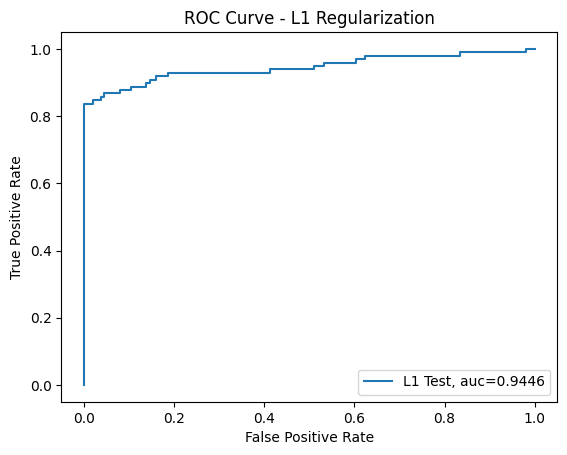


Accuracy of Logistic Regression with L2: 0.988184898439283
Confusion Matrix:


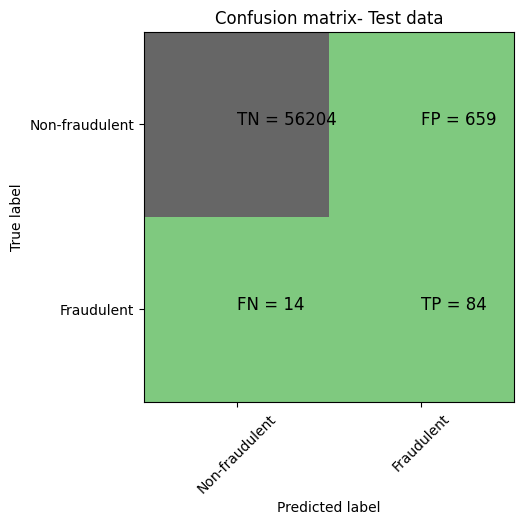

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.11      0.86      0.20        98

    accuracy                           0.99     56961
   macro avg       0.56      0.92      0.60     56961
weighted avg       1.00      0.99      0.99     56961

L2 ROC AUC: 0.9822981265031205
L2 Optimal Threshold: 0.376736372754532
ROC AUC (test): 98.2%


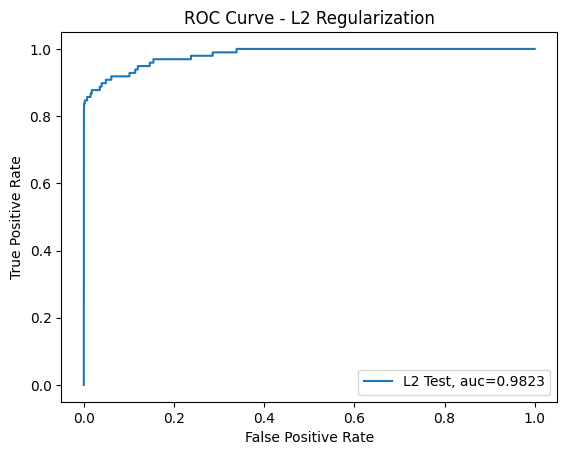

Time taken by model: --- 24277.82 seconds ---
------------------------------------------------------------
KNN Model
------------------------------------------------------------
Model score:
0.9989642035778866
Confusion Matrix:


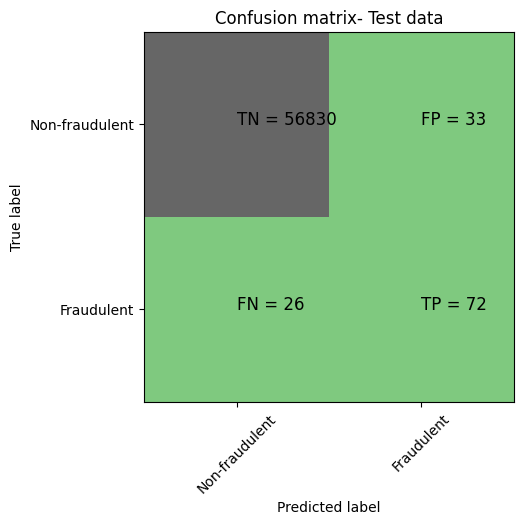

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.69      0.73      0.71        98

    accuracy                           1.00     56961
   macro avg       0.84      0.87      0.85     56961
weighted avg       1.00      1.00      1.00     56961

KNN ROC value: 0.8773414224737078
KNN Optimal Threshold: 0.2
ROC AUC (test): 87.7%


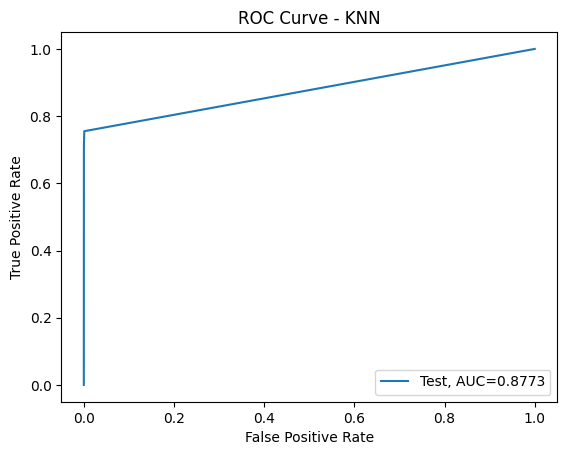

Time taken by model: --- 122.82 seconds ---
------------------------------------------------------------
Decision Tree Model
------------------------------------------------------------
gini score: 0.9991397622934991
Confusion Matrix:


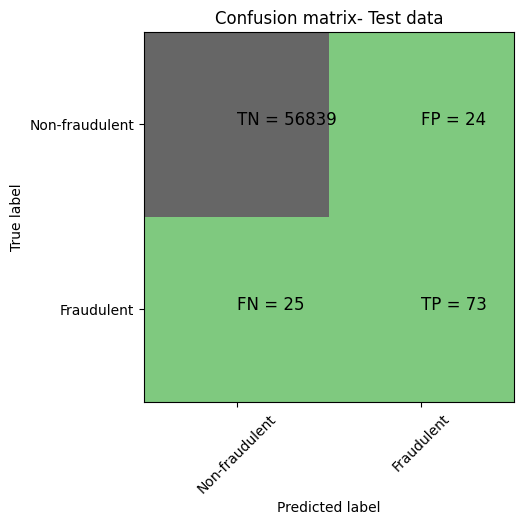

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56961
   macro avg       0.88      0.87      0.87     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8722379460550905
Tree Optimal Threshold: 1.0
ROC AUC (test): 87.2%


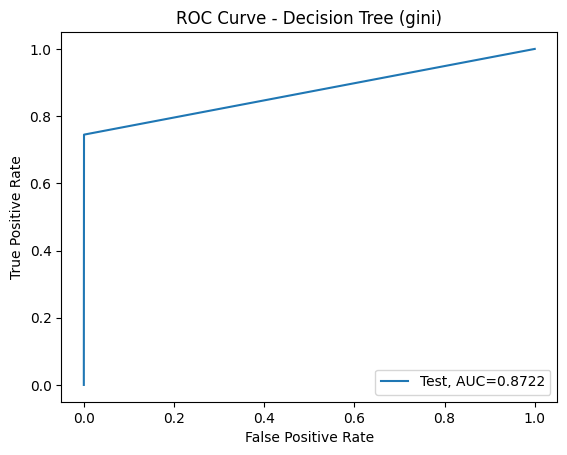

entropy score: 0.9991573181650603
Confusion Matrix:


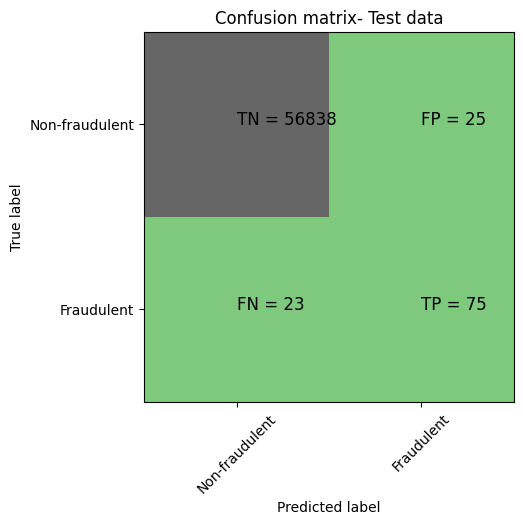

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.75      0.77      0.76        98

    accuracy                           1.00     56961
   macro avg       0.87      0.88      0.88     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8824332346237126
Tree Optimal Threshold: 1.0
ROC AUC (test): 88.2%


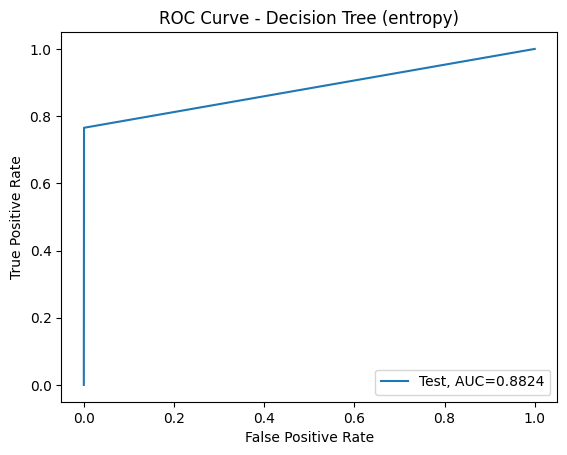

Time taken by model: --- 26.45 seconds ---
------------------------------------------------------------
Random Forest Model
------------------------------------------------------------
Model accuracy: 0.9995259914678464
Confusion Matrix:


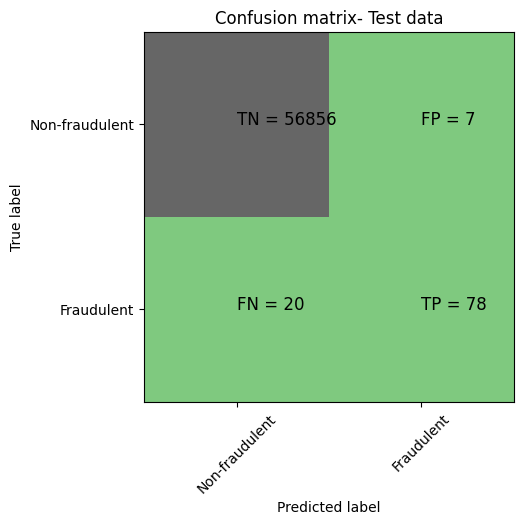

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.92      0.80      0.85        98

    accuracy                           1.00     56961
   macro avg       0.96      0.90      0.93     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest ROC value: 0.9368385238132324
Random Forest Optimal Threshold: 0.02
ROC AUC (test): 93.7%


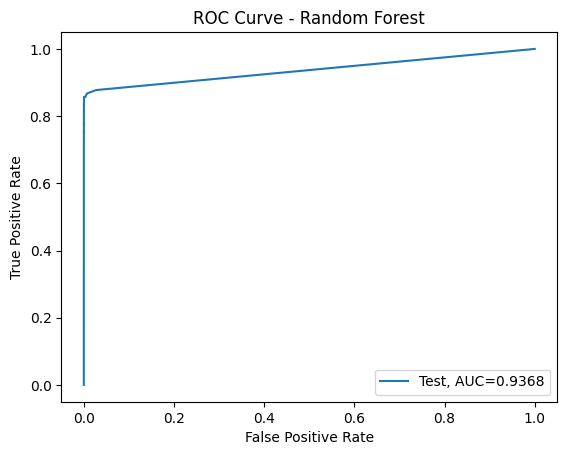

Time taken by model: --- 187.94 seconds ---
------------------------------------------------------------
XGBoost Model
------------------------------------------------------------
Model accuracy: 0.9996137708256526
Confusion Matrix:


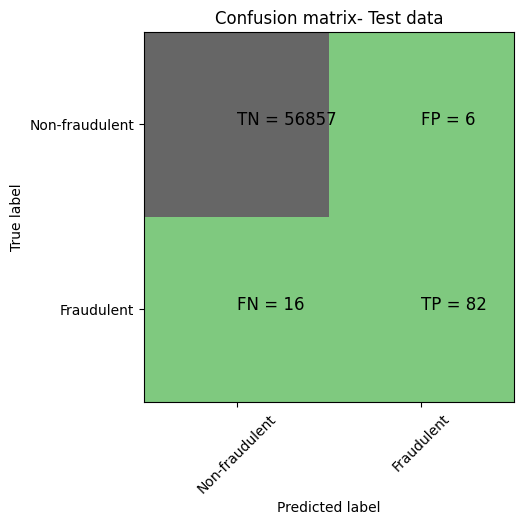

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.93      0.84      0.88        98

    accuracy                           1.00     56961
   macro avg       0.97      0.92      0.94     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost ROC value: 0.9757485499519611
XGBoost Optimal Threshold: 0.00016785251500550658
ROC AUC (test): 97.6%


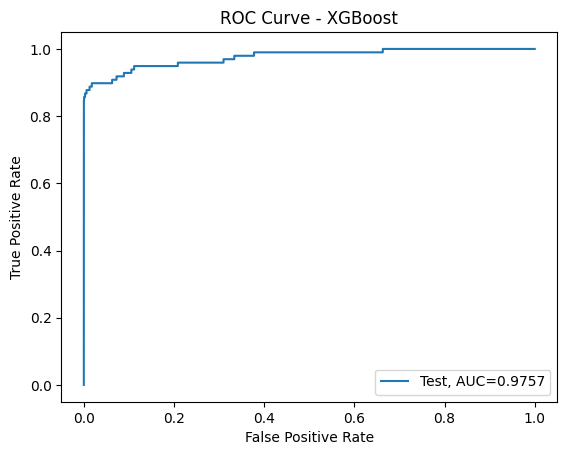

Time taken by model: --- 3.17 seconds ---
------------------------------------------------------------


In [81]:
# Logistic Regression with L1 and L2 regularization
print("Logistic Regression with L1 and L2 Regularization")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_logistic_model(df_results, "Random Oversampling with StratifiedKFold CV", X_over, y_over, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# KNN Model
print("KNN Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_knn_model(df_results, "Random Oversampling with StratifiedKFold CV", X_over, y_over, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Decision Tree Model
print("Decision Tree Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_tree_model(df_results, "Random Oversampling with StratifiedKFold CV", X_over, y_over, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Random Forest Model
print("Random Forest Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_random_forest_model(df_results, "Random Oversampling with StratifiedKFold CV", X_over, y_over, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# XGBoost Model
print("XGBoost Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_xgboost_model(df_results, "Random Oversampling with StratifiedKFold CV", X_over, y_over, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

In [82]:
df_results

,Methodology,Model,Accuracy,roc_value,Threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998244,0.567080,0.020939
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularization,0.998894,0.992277,0.001596
2,RepeatedKFold Cross Validation,KNN,0.999140,0.874746,0.200000
3,RepeatedKFold Cross Validation,Tree model with gini criteria,0.999105,0.869981,1.000000
4,RepeatedKFold Cross Validation,Tree model with entropy criteria,0.999315,0.898880,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999544,0.955501,0.020000
6,RepeatedKFold Cross Validation,XGBoost,0.999491,0.976231,0.000076
7,RepeatedKFold Cross Validation,SVM,0.998174,0.453911,0.004287
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998350,0.588759,0.012469
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularization,0.999087,0.981998,0.001879


## SMOTE Oversampling

In [85]:
# Creating the dataset with SMOTE and StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote = pd.DataFrame(data=X_train_smote, columns=cols)

Logistic Regression with L1 and L2 Regularization
------------------------------------------------------------
Max auc_roc for L1: 0.9784335851220082
Max auc_roc for L2: 0.9921995193022524

Accuracy of Logistic Regression with L1: 0.9771773669703833
Confusion Matrix:


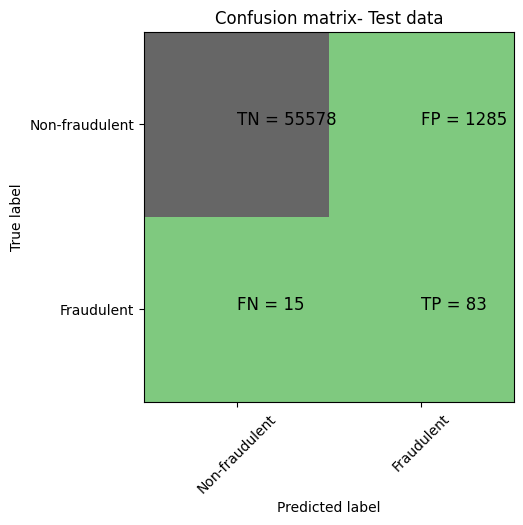

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56863
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56961
   macro avg       0.53      0.91      0.55     56961
weighted avg       1.00      0.98      0.99     56961

L1 ROC AUC: 0.9496580933694195
L1 Optimal Threshold: 0.6426659356260045
ROC AUC (test): 95.0%


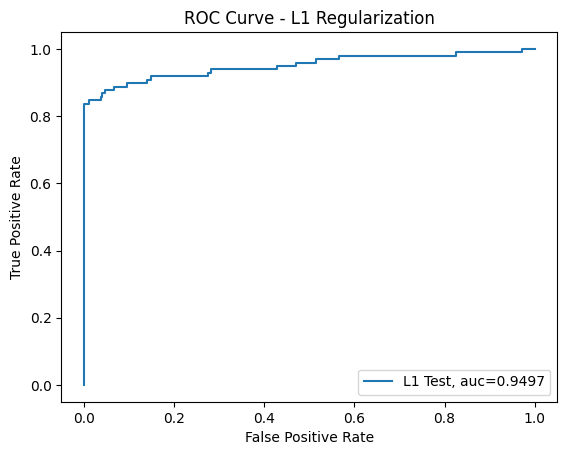


Accuracy of Logistic Regression with L2: 0.9823739049525113
Confusion Matrix:


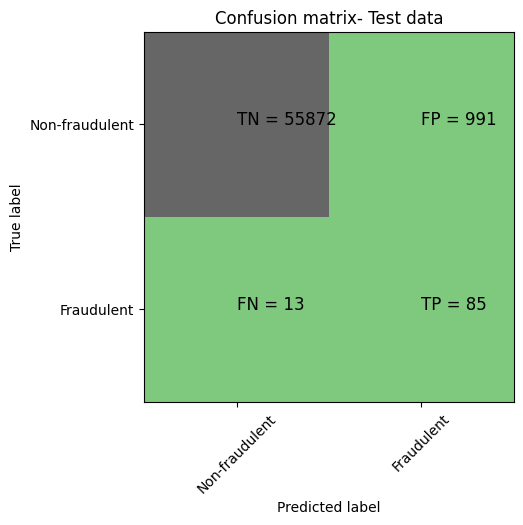

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56863
           1       0.08      0.87      0.14        98

    accuracy                           0.98     56961
   macro avg       0.54      0.92      0.57     56961
weighted avg       1.00      0.98      0.99     56961

L2 ROC AUC: 0.9793784703442252
L2 Optimal Threshold: 0.4616926202311456
ROC AUC (test): 97.9%


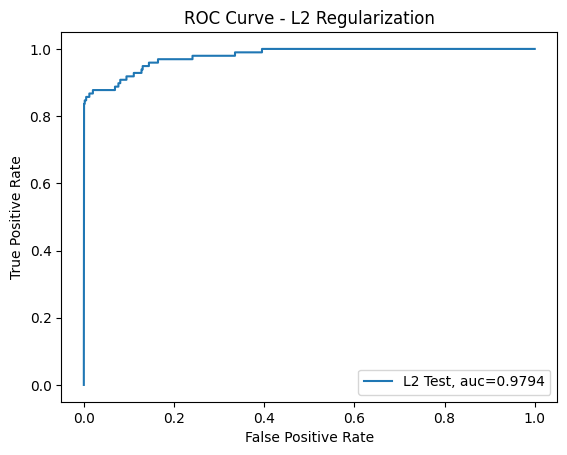

Time taken by model: --- 25689.75 seconds ---
------------------------------------------------------------
KNN Model
------------------------------------------------------------
Model score:
0.9961903758712102
Confusion Matrix:


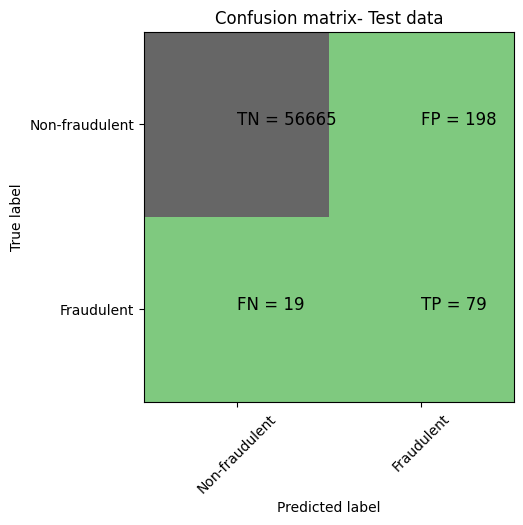

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.29      0.81      0.42        98

    accuracy                           1.00     56961
   macro avg       0.64      0.90      0.71     56961
weighted avg       1.00      1.00      1.00     56961

KNN ROC value: 0.9172028940306581
KNN Optimal Threshold: 0.2
ROC AUC (test): 91.7%


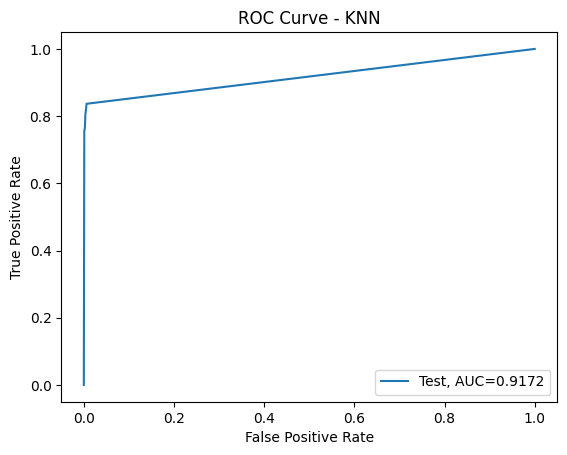

Time taken by model: --- 166.99 seconds ---
------------------------------------------------------------
Decision Tree Model
------------------------------------------------------------
gini score: 0.9972437281648847
Confusion Matrix:


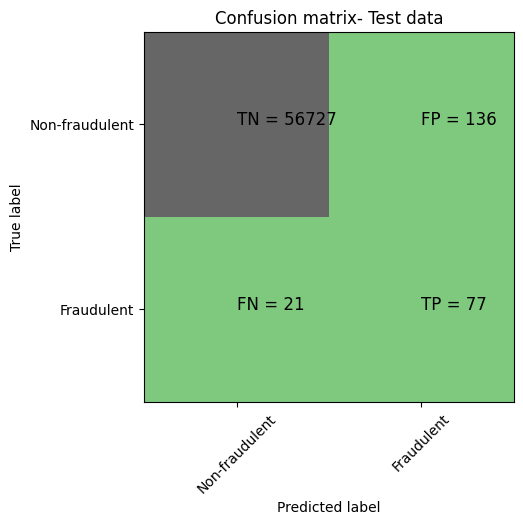

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.36      0.79      0.50        98

    accuracy                           1.00     56961
   macro avg       0.68      0.89      0.75     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8916612861489143
Tree Optimal Threshold: 1.0
ROC AUC (test): 89.2%


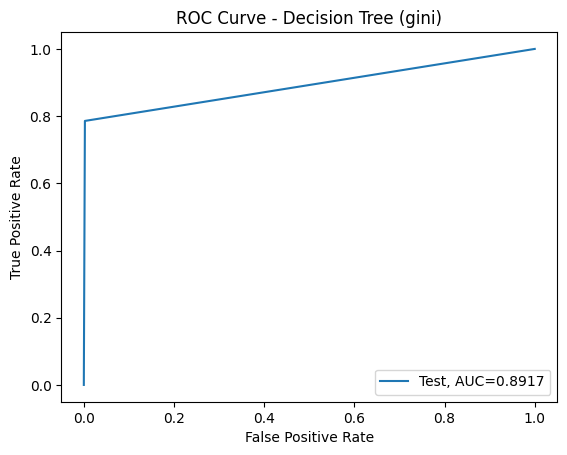

entropy score: 0.9977528484401608
Confusion Matrix:


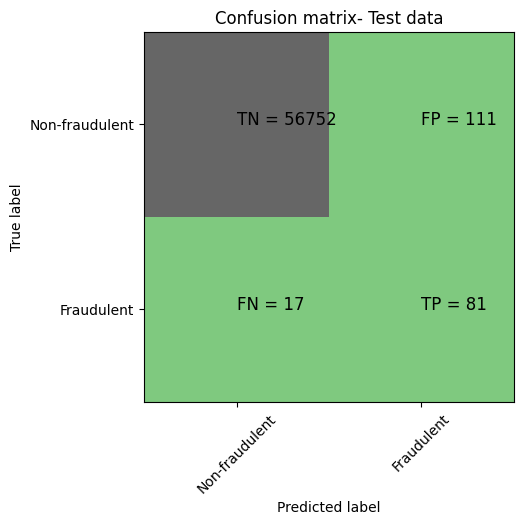

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.42      0.83      0.56        98

    accuracy                           1.00     56961
   macro avg       0.71      0.91      0.78     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.9122892760149977
Tree Optimal Threshold: 1.0
ROC AUC (test): 91.2%


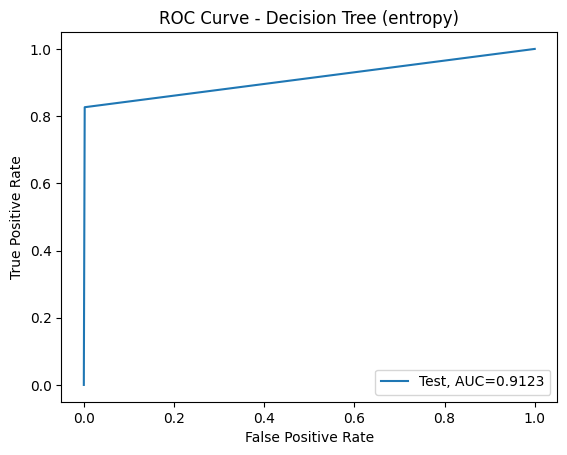

Time taken by model: --- 76.18 seconds ---
------------------------------------------------------------
Random Forest Model
------------------------------------------------------------
Model accuracy: 0.9994557679816014
Confusion Matrix:


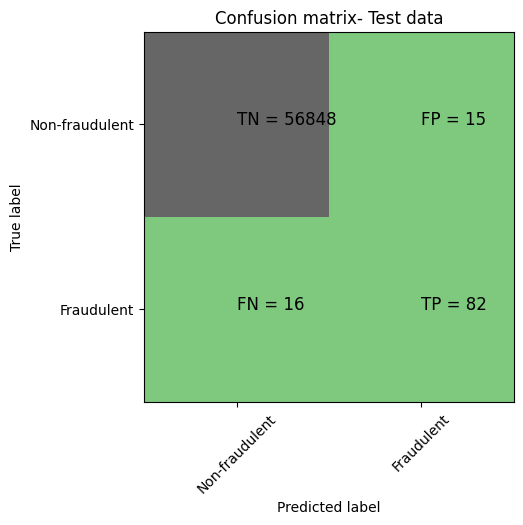

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56961
   macro avg       0.92      0.92      0.92     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest ROC value: 0.9688535315995803
Random Forest Optimal Threshold: 0.04
ROC AUC (test): 96.9%


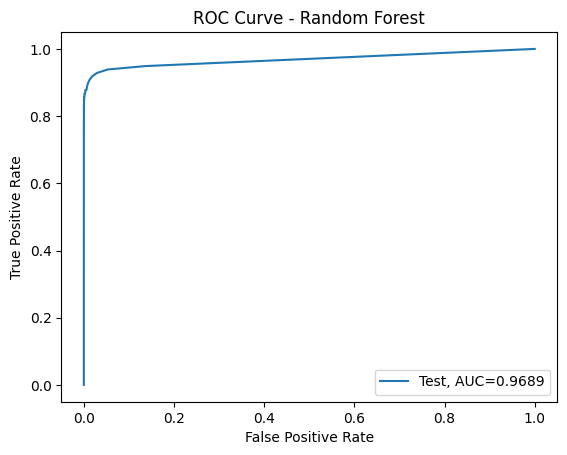

Time taken by model: --- 434.14 seconds ---
------------------------------------------------------------
XGBoost Model
------------------------------------------------------------
Model accuracy: 0.999350432752234
Confusion Matrix:


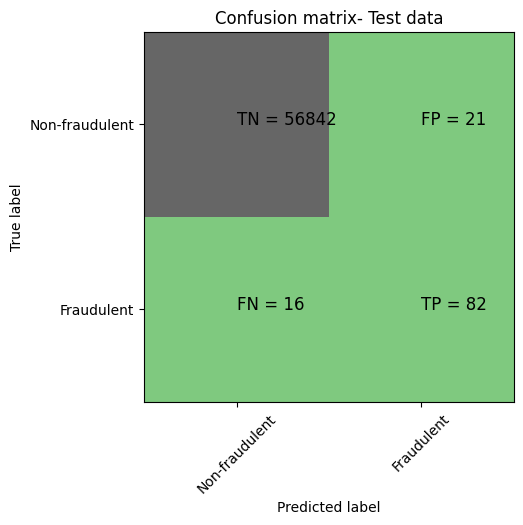

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.80      0.84      0.82        98

    accuracy                           1.00     56961
   macro avg       0.90      0.92      0.91     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost ROC value: 0.980450506354873
XGBoost Optimal Threshold: 0.00018297745555173606
ROC AUC (test): 98.0%


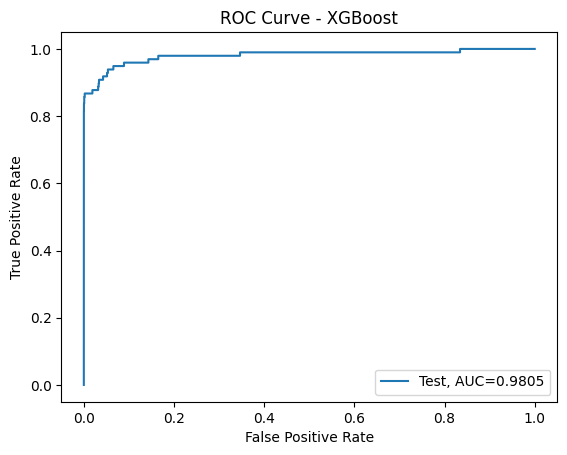

Time taken by model: --- 5.08 seconds ---
------------------------------------------------------------


In [86]:
# Logistic Regression with L1 and L2 regularization
print("Logistic Regression with L1 and L2 Regularization")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_logistic_model(df_results, "SMOTE Oversampling with StratifiedKFold CV", X_train_smote, y_train_smote, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# KNN Model
print("KNN Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_knn_model(df_results, "SMOTE Oversampling with StratifiedKFold CV", X_train_smote, y_train_smote, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Decision Tree Model
print("Decision Tree Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_tree_model(df_results, "SMOTE Oversampling with StratifiedKFold CV", X_train_smote, y_train_smote, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Random Forest Model
print("Random Forest Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_random_forest_model(df_results, "SMOTE Oversampling with StratifiedKFold CV", X_train_smote, y_train_smote, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# XGBoost Model
print("XGBoost Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_xgboost_model(df_results, "SMOTE Oversampling with StratifiedKFold CV", X_train_smote, y_train_smote, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

In [87]:
df_results

,Methodology,Model,Accuracy,roc_value,Threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998244,0.567080,0.020939
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularization,0.998894,0.992277,0.001596
2,RepeatedKFold Cross Validation,KNN,0.999140,0.874746,0.200000
3,RepeatedKFold Cross Validation,Tree model with gini criteria,0.999105,0.869981,1.000000
4,RepeatedKFold Cross Validation,Tree model with entropy criteria,0.999315,0.898880,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999544,0.955501,0.020000
6,RepeatedKFold Cross Validation,XGBoost,0.999491,0.976231,0.000076
7,RepeatedKFold Cross Validation,SVM,0.998174,0.453911,0.004287
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998350,0.588759,0.012469
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularization,0.999087,0.981998,0.001879


## ADASYN Oversampling

In [91]:
# Creating the dataset with ADASYN and StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]
    adasyn = ADASYN(random_state=42)
    X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

X_train_adasyn = pd.DataFrame(data=X_train_adasyn, columns=cols)

Logistic Regression with L1 and L2 Regularization
------------------------------------------------------------
Max auc_roc for L1: 0.961399002593929
Max auc_roc for L2: 0.9817098614811064

Accuracy of Logistic Regression with L1: 0.9444181106371026
Confusion Matrix:


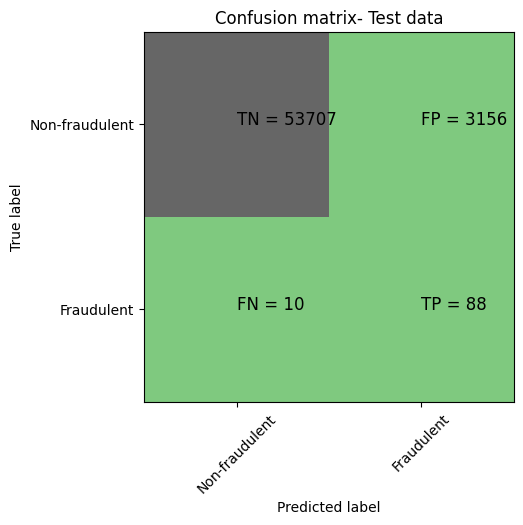

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56863
           1       0.03      0.90      0.05        98

    accuracy                           0.94     56961
   macro avg       0.51      0.92      0.51     56961
weighted avg       1.00      0.94      0.97     56961

L1 ROC AUC: 0.9645083223659301
L1 Optimal Threshold: 0.5507086257236234
ROC AUC (test): 96.5%


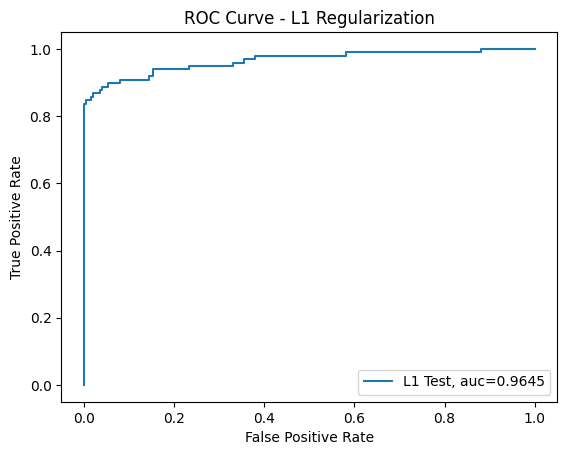


Accuracy of Logistic Regression with L2: 0.9570232264180756
Confusion Matrix:


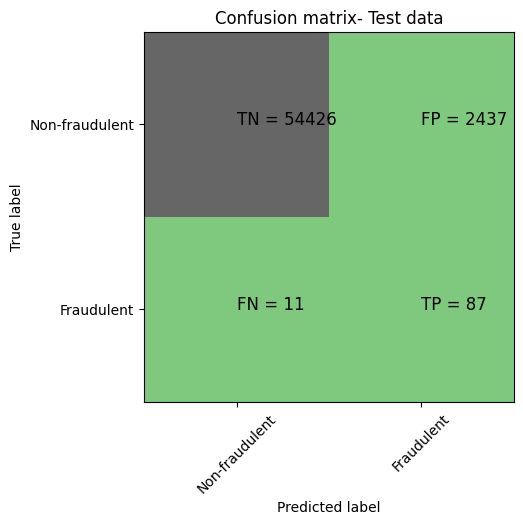

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56863
           1       0.03      0.89      0.07        98

    accuracy                           0.96     56961
   macro avg       0.52      0.92      0.52     56961
weighted avg       1.00      0.96      0.98     56961

L2 ROC AUC: 0.9739109790197492
L2 Optimal Threshold: 0.7715342169039112
ROC AUC (test): 97.4%


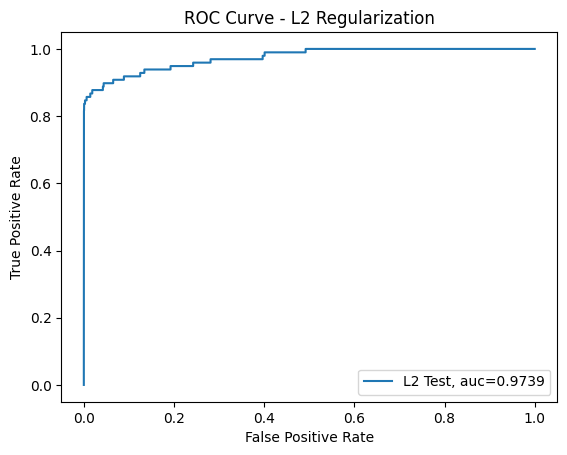

Time taken by model: --- 24686.12 seconds ---
------------------------------------------------------------
KNN Model
------------------------------------------------------------
Model score:
0.9958743701831078
Confusion Matrix:


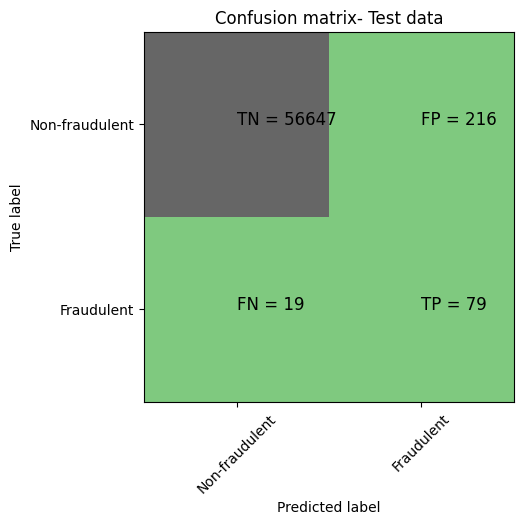

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.27      0.81      0.40        98

    accuracy                           1.00     56961
   macro avg       0.63      0.90      0.70     56961
weighted avg       1.00      1.00      1.00     56961

KNN ROC value: 0.9170785349822183
KNN Optimal Threshold: 0.2
ROC AUC (test): 91.7%


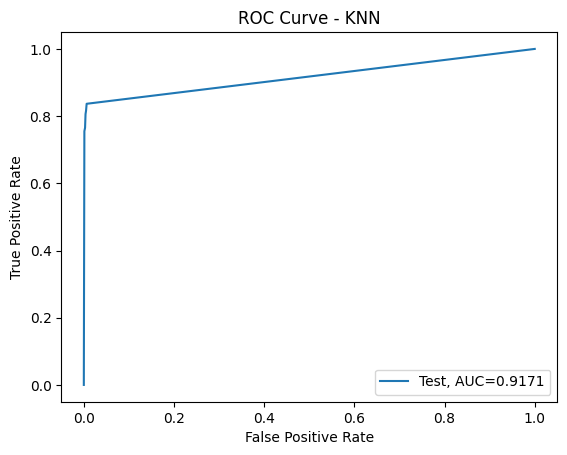

Time taken by model: --- 165.77 seconds ---
------------------------------------------------------------
Decision Tree Model
------------------------------------------------------------
gini score: 0.9974719544951809
Confusion Matrix:


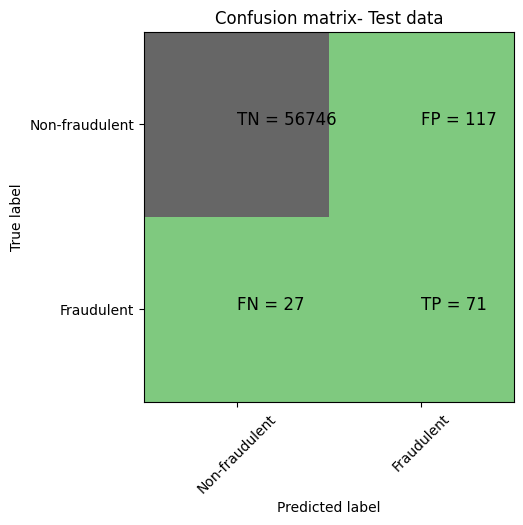

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.38      0.72      0.50        98

    accuracy                           1.00     56961
   macro avg       0.69      0.86      0.75     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8612161094675459
Tree Optimal Threshold: 1.0
ROC AUC (test): 86.1%


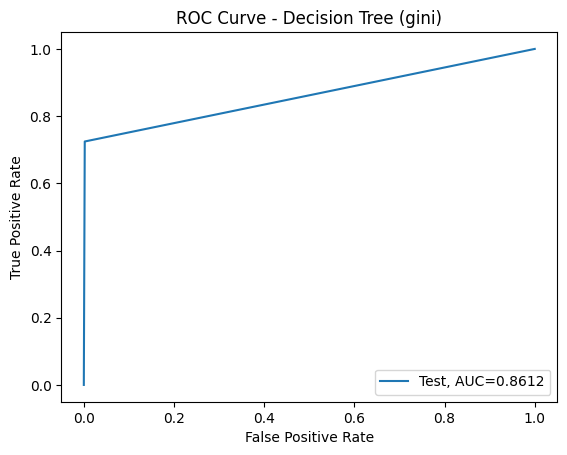

entropy score: 0.9976475132107934
Confusion Matrix:


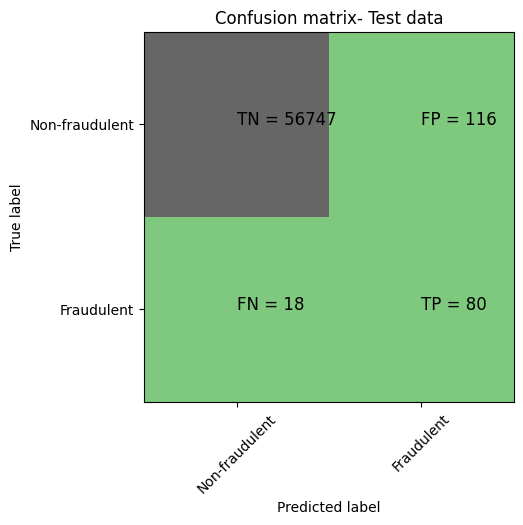

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.41      0.82      0.54        98

    accuracy                           1.00     56961
   macro avg       0.70      0.91      0.77     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.9071432698785158
Tree Optimal Threshold: 1.0
ROC AUC (test): 90.7%


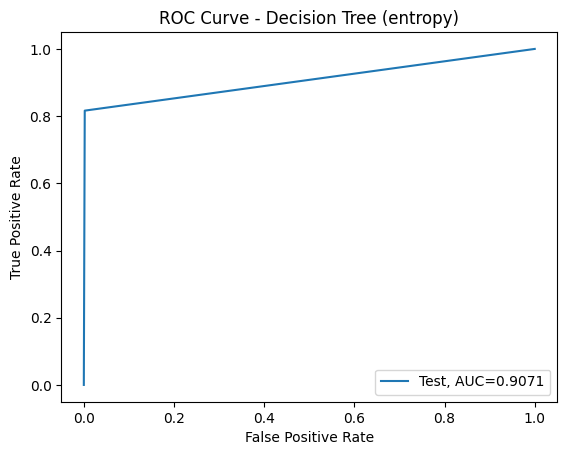

Time taken by model: --- 84.19 seconds ---
------------------------------------------------------------
Random Forest Model
------------------------------------------------------------
Model accuracy: 0.999350432752234
Confusion Matrix:


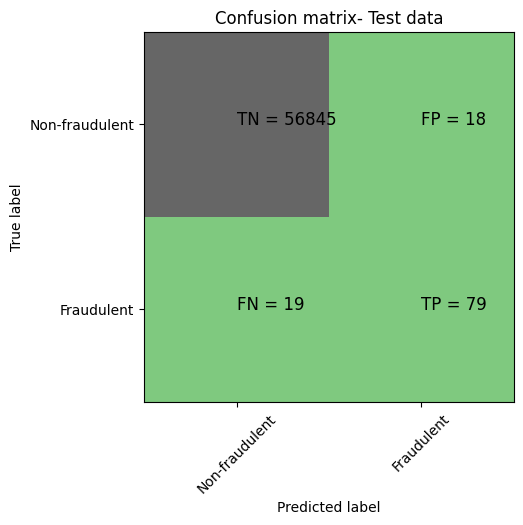

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56961
   macro avg       0.91      0.90      0.90     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest ROC value: 0.9692603453987332
Random Forest Optimal Threshold: 0.02
ROC AUC (test): 96.9%


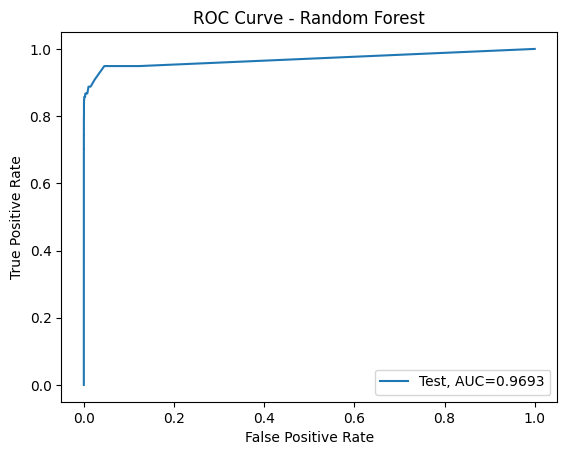

Time taken by model: --- 426.95 seconds ---
------------------------------------------------------------
XGBoost Model
------------------------------------------------------------
Model accuracy: 0.999280209265989
Confusion Matrix:


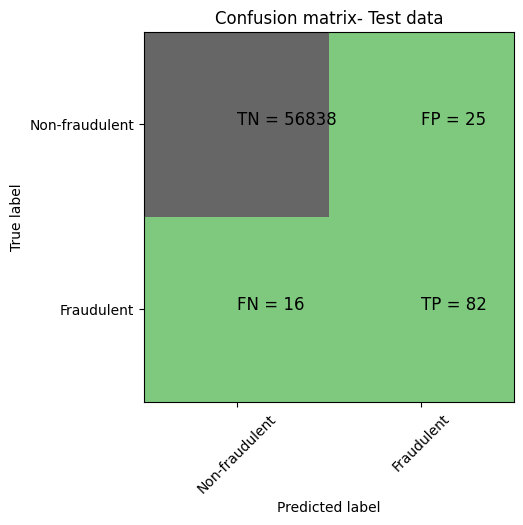

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.77      0.84      0.80        98

    accuracy                           1.00     56961
   macro avg       0.88      0.92      0.90     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost ROC value: 0.9814894337876896
XGBoost Optimal Threshold: 0.0006223960081115365
ROC AUC (test): 98.1%


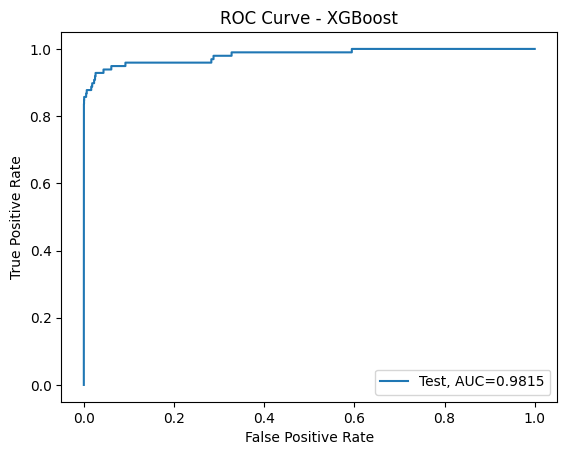

Time taken by model: --- 5.26 seconds ---
------------------------------------------------------------


In [92]:
# Logistic Regression with L1 and L2 regularization
print("Logistic Regression with L1 and L2 Regularization")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_logistic_model(df_results, "ADASYN Oversampling with StratifiedKFold CV", X_train_adasyn, y_train_adasyn, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# KNN Model
print("KNN Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_knn_model(df_results, "ADASYN Oversampling with StratifiedKFold CV", X_train_adasyn, y_train_adasyn, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Decision Tree Model
print("Decision Tree Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_tree_model(df_results, "ADASYN Oversampling with StratifiedKFold CV", X_train_adasyn, y_train_adasyn, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# Random Forest Model
print("Random Forest Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_random_forest_model(df_results, "ADASYN Oversampling with StratifiedKFold CV", X_train_adasyn, y_train_adasyn, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

# XGBoost Model
print("XGBoost Model")
print("-" * 60)
start_time = time.time()
df_results = build_and_run_xgboost_model(df_results, "ADASYN Oversampling with StratifiedKFold CV", X_train_adasyn, y_train_adasyn, X_test, y_test)
print("Time taken by model: --- {:.2f} seconds ---".format(time.time() - start_time))
print("-" * 60)

In [93]:
df_results

,Methodology,Model,Accuracy,roc_value,Threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998244,0.567080,0.020939
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularization,0.998894,0.992277,0.001596
2,RepeatedKFold Cross Validation,KNN,0.999140,0.874746,0.200000
3,RepeatedKFold Cross Validation,Tree model with gini criteria,0.999105,0.869981,1.000000
4,RepeatedKFold Cross Validation,Tree model with entropy criteria,0.999315,0.898880,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999544,0.955501,0.020000
6,RepeatedKFold Cross Validation,XGBoost,0.999491,0.976231,0.000076
7,RepeatedKFold Cross Validation,SVM,0.998174,0.453911,0.004287
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularization,0.998350,0.588759,0.012469
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularization,0.999087,0.981998,0.001879


# Hyperparameter Tuning: XGBoost

In [117]:
# Performing hyperparameter tuning
param_test = {
    "max_depth": list(range(3, 10, 2)),
    "min_child_weight": list(range(1, 6, 2)),
    "n_estimators": list(range(60, 220, 40)),
    "learning_rate": [0.05, 0.1, 0.125, 0.15, 0.2],
    "gamma": [i/10.0 for i in range(0, 5)],
    "subsample": [i/10.0 for i in range(7, 10)],
    "colsample_bytree": [i/10.0 for i in range(7, 10)]
}

gsearch1 = RandomizedSearchCV(
    estimator=XGBClassifier(
        base_score=0.5,
        booster="gbtree",
        colsample_bylevel=1,
        colsample_bynode=1,
        max_delta_step=0,
        objective="binary:logistic",
        random_state=42,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=1,
        verbosity=1
    ),
    param_distributions=param_test,
    n_iter=50,             
    scoring="roc_auc",
    n_jobs=-1,
    cv=5,
    random_state=42  
)

gsearch1.fit(X_over, y_over)
print("Best Parameters:", gsearch1.best_params_)
print("Best ROC AUC Score:", gsearch1.best_score_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 180, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best ROC AUC Score: 0.9999524986451667


XGBoost Accuracy: 0.9993328768806727
XGBoost ROC value: 0.9825037765312762
XGBoost Optimal Threshold: 0.014048011973500252
ROC AUC (test): 98.3%


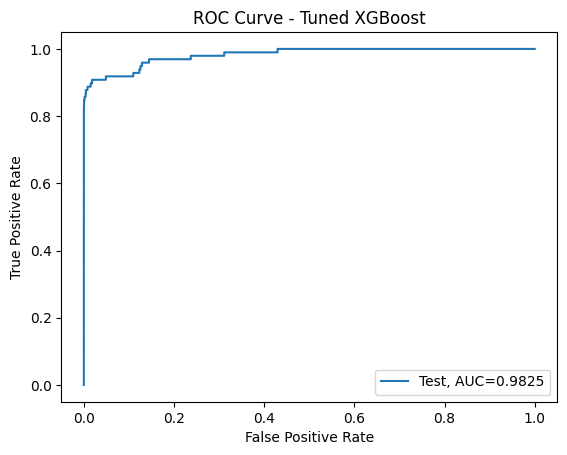

In [119]:
# Creating XGBoost model with selected hyperparameters
clf = XGBClassifier(
    base_score=0.5,
    booster="gbtree",
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=0.7,
    gamma=0.2,
    learning_rate=0.125,
    max_delta_step=0,
    max_depth=7,
    min_child_weight=5,
    n_estimators=60,
    objective="binary:logistic",
    random_state=42,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=0.8,
    verbosity=1
)

clf.fit(X_over, y_over)

xgb_test_score = clf.score(X_test, y_test)
print("XGBoost Accuracy: {0}".format(xgb_test_score))

xgb_probs = clf.predict_proba(X_test)[:, 1]
xgb_roc_value = roc_auc_score(y_test, xgb_probs)
print("XGBoost ROC value: {0}".format(xgb_roc_value))

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
threshold = thresholds[np.argmax(tpr - fpr)]
print("XGBoost Optimal Threshold: {0}".format(threshold))

roc_auc = auc(fpr, tpr)
print("ROC AUC (test):", "{:.1%}".format(roc_auc))
plt.plot(fpr, tpr, label="Test, AUC=" + str(round(roc_auc, 4)))
plt.title("ROC Curve - Tuned XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

df_results = pd.concat([df_results, pd.DataFrame({
    "Methodology": ["Random Oversampling with StratifiedKFold CV + Hyperparameter Tuning"],
    "Model": ["Tuned XGBoost"],
    "Accuracy": [xgb_test_score],
    "roc_value": [xgb_roc_value],
    "Threshold": [threshold]
})], ignore_index=True)


XGBoost Feature Importance:


<Figure size 1200x600 with 0 Axes>

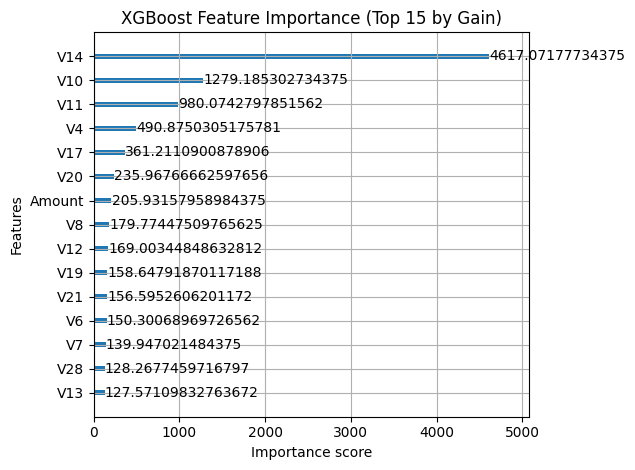

In [121]:
# XGBoost feature importance
print("\nXGBoost Feature Importance:")
plt.figure(figsize=(12, 6))
plot_importance(clf, max_num_features=15, importance_type="gain")
plt.title("XGBoost Feature Importance (Top 15 by Gain)", fontsize=12)
plt.tight_layout()
plt.show()

FINAL RESULTS SUMMARY

All models sorted by ROC AUC:
                                                            Methodology                                       Model  Accuracy  roc_value  Threshold
0                                        RepeatedKFold Cross Validation  Logistic Regression with L2 Regularization  0.998894   0.992277   0.001596
1   Random Oversampling with StratifiedKFold CV + Hyperparameter Tuning                               Tuned XGBoost  0.999333   0.982504   0.014048
2                           Random Oversampling with StratifiedKFold CV  Logistic Regression with L2 Regularization  0.988185   0.982298   0.376736
3                                      StratifiedKFold Cross Validation  Logistic Regression with L2 Regularization  0.999087   0.981998   0.001879
4                           ADASYN Oversampling with StratifiedKFold CV                                     XGBoost  0.999280   0.981489   0.000622
5                            SMOTE Oversampling with Strati

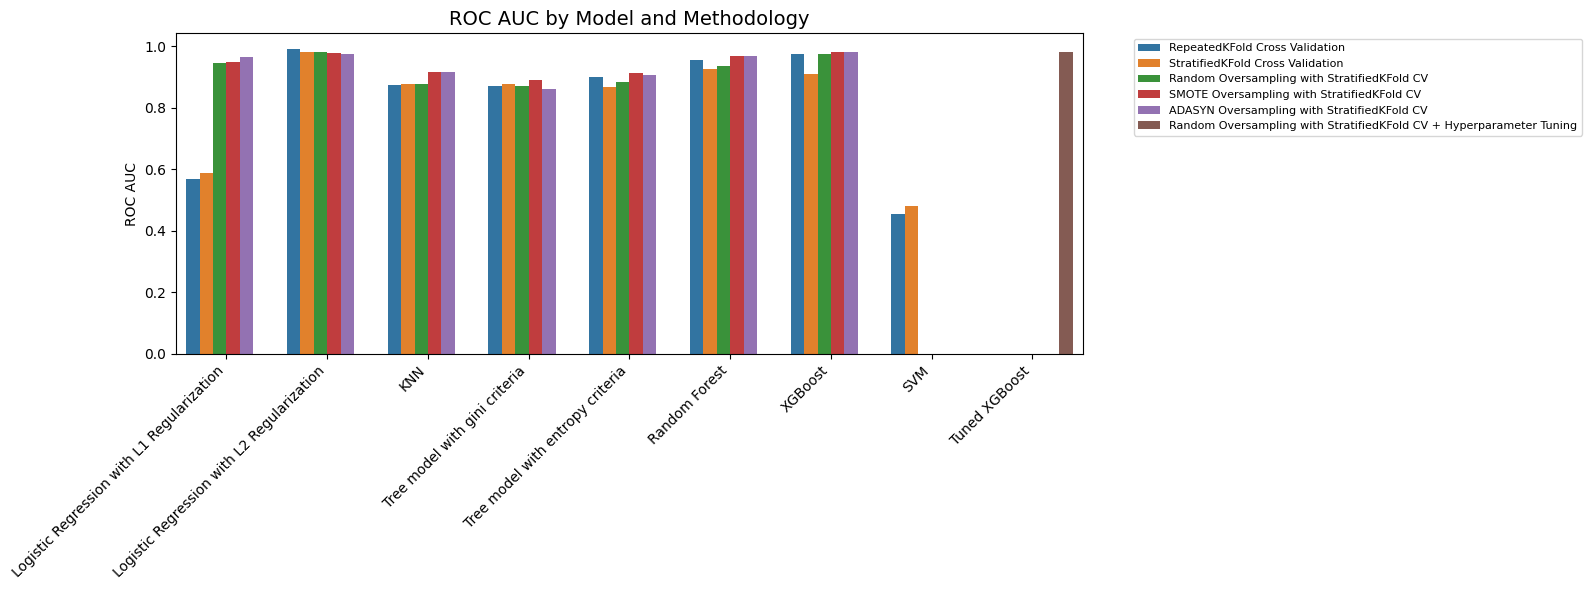

In [123]:
# Final results comparison
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

# Full results sorted by ROC AUC
print("\nAll models sorted by ROC AUC:")
print(df_results.sort_values(by="roc_value", ascending=False).reset_index(drop=True).to_string())

# Average ROC AUC per methodology
print("\nAverage ROC AUC per Methodology:")
print(df_results.groupby("Methodology")["roc_value"].mean().sort_values(ascending=False))

# Best model per methodology
print("\nBest Model per Methodology:")
best_per_methodology = df_results.loc[df_results.groupby("Methodology")["roc_value"].idxmax()][
    ["Methodology", "Model", "roc_value", "Accuracy", "Threshold"]
].sort_values(by="roc_value", ascending=False).reset_index(drop=True)
print(best_per_methodology.to_string())

# Visualise ROC AUC by model and methodology
plt.figure(figsize=(16, 6))
sns.barplot(data=df_results, x="Model", y="roc_value", hue="Methodology")
plt.title("ROC AUC by Model and Methodology", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC AUC")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()